# Modelado de churn - Cierre final

Este notebook documenta la construccion de baselines, el arbol obligatorio y el cierre del modelo final.

El protocolo final incorpora dos correcciones conservadoras:

- perfiles con variables explicativas identicas se mantienen en el mismo grupo para que no aparezcan simultaneamente en train y test;
- `Complain` y `DaySinceLastOrder` se excluyen del modelo final porque no existe evidencia suficiente sobre su disponibilidad antes del churn.

La metrica principal es F2 (`beta=2`), complementada con recall, precision, PR-AUC, ROC-AUC y volumen de contactos.


In [1]:
from pathlib import Path

import pandas as pd
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer, KNNImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

DATA_PATH = Path("E Commerce Dataset.xlsx - E Comm.csv")
RANDOM_STATE = 42
TEST_SIZE = 0.20
TARGET = "Churn"
ID_COL = "CustomerID"

df_raw = pd.read_csv(DATA_PATH)
missing_cols = df_raw.columns[df_raw.isna().any()].tolist()

df_raw.head()


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.000,Mobile Phone,3,6.000,Debit Card,Female,3.000,3,Laptop & Accessory,2,Single,9,1,11.000,1.000,1.000,5.000,160
1,50002,1,NaN,Phone,1,8.000,UPI,Male,3.000,4,Mobile,3,Single,7,1,15.000,0.000,1.000,0.000,121
2,50003,1,NaN,Phone,1,30.000,Debit Card,Male,2.000,4,Mobile,3,Single,6,1,14.000,0.000,1.000,3.000,120
3,50004,1,0.000,Phone,3,15.000,Debit Card,Male,2.000,4,Laptop & Accessory,5,Single,8,0,23.000,0.000,1.000,3.000,134
4,50005,1,0.000,Phone,1,12.000,CC,Male,NaN,3,Mobile,5,Single,3,0,11.000,1.000,1.000,3.000,130


## 1. Definicion de X e y

`CustomerID` no entra como predictor porque es un identificador, no una senal de comportamiento. `Churn` se separa como variable objetivo.

Todavia no se imputan nulos ni se codifican categorias. Esas transformaciones tienen que vivir en el pipeline de entrenamiento para evitar fuga de informacion desde test hacia train.

In [2]:
feature_cols = [col for col in df_raw.columns if col not in [ID_COL, TARGET]]

X = df_raw[feature_cols].copy()
y = df_raw[TARGET].copy()

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Churn rate total: {y.mean() * 100:.2f}%")

X.head()

X shape: (5630, 18)
y shape: (5630,)
Churn rate total: 16.84%


,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,4.000,Mobile Phone,3,6.000,Debit Card,Female,3.000,3,Laptop & Accessory,2,Single,9,1,11.000,1.000,1.000,5.000,160
1,NaN,Phone,1,8.000,UPI,Male,3.000,4,Mobile,3,Single,7,1,15.000,0.000,1.000,0.000,121
2,NaN,Phone,1,30.000,Debit Card,Male,2.000,4,Mobile,3,Single,6,1,14.000,0.000,1.000,3.000,120
3,0.000,Phone,3,15.000,Debit Card,Male,2.000,4,Laptop & Accessory,5,Single,8,0,23.000,0.000,1.000,3.000,134
4,0.000,Phone,1,12.000,CC,Male,NaN,3,Mobile,5,Single,3,0,11.000,1.000,1.000,3.000,130


## 2. Split train/test estratificado por perfiles

La auditoria detecto 556 filas con variables explicativas exactamente duplicadas. Un split aleatorio dejaba perfiles identicos en train y test, lo que podia inflar las metricas.

Para evitarlo se utiliza `StratifiedGroupKFold`: conserva aproximadamente la proporcion de churn y obliga a que todas las copias de un mismo perfil queden del mismo lado. El primer fold se reserva como test final y los cuatro restantes forman train.


In [3]:
def profile_groups(data):
    normalized = data.astype(object).where(data.notna(), "__MISSING__").astype(str)
    return pd.util.hash_pandas_object(normalized, index=False).astype(str)


profile_group = profile_groups(X)
outer_split = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)
train_positions, test_positions = next(
    outer_split.split(X, y, groups=profile_group)
)

X_train = X.iloc[train_positions].copy()
X_test = X.iloc[test_positions].copy()
y_train = y.iloc[train_positions].copy()
y_test = y.iloc[test_positions].copy()
train_groups = profile_group.iloc[train_positions].copy()
test_groups = profile_group.iloc[test_positions].copy()

split_summary = pd.DataFrame({
    "dataset": ["total", "train", "test"],
    "filas": [len(y), len(y_train), len(y_test)],
    "clientes_churn": [int(y.sum()), int(y_train.sum()), int(y_test.sum())],
    "clientes_no_churn": [
        int((y == 0).sum()),
        int((y_train == 0).sum()),
        int((y_test == 0).sum()),
    ],
    "tasa_churn_%": [
        round(y.mean() * 100, 2),
        round(y_train.mean() * 100, 2),
        round(y_test.mean() * 100, 2),
    ],
})

split_summary


,dataset,filas,clientes_churn,clientes_no_churn,tasa_churn_%
0,total,5630,948,4682,16.840
1,train,4504,758,3746,16.830
2,test,1126,190,936,16.870


## 3. Validaciones del split

Estas validaciones confirman que no se perdieron filas, que los identificadores no se superponen y, especialmente, que ningun perfil duplicado aparece simultaneamente en train y test.


In [4]:
train_ids = set(df_raw.loc[X_train.index, ID_COL])
test_ids = set(df_raw.loc[X_test.index, ID_COL])
shared_profiles = set(train_groups).intersection(set(test_groups))

assert len(X_train) + len(X_test) == len(df_raw)
assert len(train_ids.intersection(test_ids)) == 0
assert X_train.index.intersection(X_test.index).empty
assert y_train.sum() + y_test.sum() == y.sum()
assert len(shared_profiles) == 0

print("Validaciones OK")
print(f"Filas duplicadas por features detectadas: {X.duplicated().sum():,}")
print(f"Filas train: {len(X_train):,}")
print(f"Filas test: {len(X_test):,}")
print(f"Churn train: {y_train.mean() * 100:.2f}%")
print(f"Churn test: {y_test.mean() * 100:.2f}%")
print(f"Perfiles compartidos train/test: {len(shared_profiles)}")


Validaciones OK
Filas duplicadas por features detectadas: 556
Filas train: 4,504
Filas test: 1,126
Churn train: 16.83%
Churn test: 16.87%
Perfiles compartidos train/test: 0


## 4. Imputacion planificada despues del split

La imputacion del EDA sirvio para analizar sin perder filas. Para modelado se recalcula despues del split para evitar leakage.

Criterio acordado:

- `WarehouseToHome` y `CouponUsed`: imputacion por mediana calculada solo con train.
- `Tenure`, `HourSpendOnApp`, `OrderAmountHikeFromlastYear`, `OrderCount` y `DaySinceLastOrder`: comparar KNN vs regresion iterativa usando solo train y elegir el menor MAE por variable.
- Test se transforma con los parametros aprendidos en train.

In [5]:
median_imputation_cols = ["WarehouseToHome", "CouponUsed"]
model_imputation_cols = [
    "Tenure",
    "HourSpendOnApp",
    "OrderAmountHikeFromlastYear",
    "OrderCount",
    "DaySinceLastOrder",
]

numeric_imputation_features = [
    "Tenure",
    "WarehouseToHome",
    "HourSpendOnApp",
    "OrderAmountHikeFromlastYear",
    "CouponUsed",
    "OrderCount",
    "DaySinceLastOrder",
    "CityTier",
    "NumberOfDeviceRegistered",
    "SatisfactionScore",
    "NumberOfAddress",
    "Complain",
    "CashbackAmount",
]

train_medians = X_train[median_imputation_cols].median()

X_train_imputation_base = X_train[numeric_imputation_features].copy()
X_test_imputation_base = X_test[numeric_imputation_features].copy()

for col in median_imputation_cols:
    X_train_imputation_base[col] = X_train_imputation_base[col].fillna(train_medians[col])
    X_test_imputation_base[col] = X_test_imputation_base[col].fillna(train_medians[col])

pd.DataFrame({
    "variable": median_imputation_cols,
    "mediana_train": [train_medians[col] for col in median_imputation_cols],
    "nulos_train_antes": [int(X_train[col].isna().sum()) for col in median_imputation_cols],
    "nulos_test_antes": [int(X_test[col].isna().sum()) for col in median_imputation_cols],
})

,variable,mediana_train,nulos_train_antes,nulos_test_antes
0,WarehouseToHome,14.000,196,55
1,CouponUsed,1.000,212,44


In [6]:
def fit_scaled_imputer(data, imputer):
    """Ajusta scaler e imputador sobre train y devuelve ambos objetos junto con la matriz imputada."""
    scaler = StandardScaler()
    X_scaled = pd.DataFrame(
        scaler.fit_transform(data),
        columns=data.columns,
        index=data.index,
    )
    X_imputed_scaled = imputer.fit_transform(X_scaled)
    X_imputed = pd.DataFrame(
        scaler.inverse_transform(X_imputed_scaled),
        columns=data.columns,
        index=data.index,
    )
    return scaler, imputer, X_imputed


def transform_scaled_imputer(data, scaler, imputer):
    X_scaled = pd.DataFrame(
        scaler.transform(data),
        columns=data.columns,
        index=data.index,
    )
    X_imputed_scaled = imputer.transform(X_scaled)
    return pd.DataFrame(
        scaler.inverse_transform(X_imputed_scaled),
        columns=data.columns,
        index=data.index,
    )


def evaluate_scaled_imputer_for_column(data, target_col, imputer, random_state=RANDOM_STATE, mask_fraction=0.20):
    observed_idx = data.index[data[target_col].notna()].to_numpy()
    rng = pd.Series(observed_idx).sample(
        n=max(1, int(len(observed_idx) * mask_fraction)),
        random_state=random_state,
    ).to_numpy()

    X_masked = data.copy()
    y_true = X_masked.loc[rng, target_col].copy()
    X_masked.loc[rng, target_col] = pd.NA

    _, _, X_imputed = fit_scaled_imputer(X_masked, imputer)
    y_pred = X_imputed.loc[rng, target_col]
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "n_validacion": len(rng),
    }


imputer_specs = {
    "knn_k5": KNNImputer(n_neighbors=5, weights="distance"),
    "iterative_regression": IterativeImputer(
        random_state=RANDOM_STATE,
        max_iter=20,
        initial_strategy="median",
        sample_posterior=False,
    ),
}

imputation_results = []
for target_col in model_imputation_cols:
    for method, imputer in imputer_specs.items():
        metrics = evaluate_scaled_imputer_for_column(
            X_train_imputation_base,
            target_col=target_col,
            imputer=imputer,
        )
        imputation_results.append({
            "variable": target_col,
            "metodo": method,
            **metrics,
        })

imputation_results = pd.DataFrame(imputation_results)
best_imputer_by_variable = imputation_results.loc[
    imputation_results.groupby("variable")["MAE"].idxmin()
].sort_values("variable")

imputation_results.sort_values(["variable", "MAE"])

,variable,metodo,MAE,RMSE,n_validacion
8,DaySinceLastOrder,knn_k5,1.550,2.627,851
9,DaySinceLastOrder,iterative_regression,2.421,3.270,851
2,HourSpendOnApp,knn_k5,0.401,0.572,859
3,HourSpendOnApp,iterative_regression,0.532,0.664,859
4,OrderAmountHikeFromlastYear,knn_k5,2.069,2.999,860
5,OrderAmountHikeFromlastYear,iterative_regression,2.974,3.521,860
6,OrderCount,knn_k5,0.781,1.597,858
7,OrderCount,iterative_regression,1.257,1.870,858
0,Tenure,knn_k5,3.884,5.917,857
1,Tenure,iterative_regression,5.966,7.582,857


In [7]:
fitted_imputers = {}

for method, imputer in imputer_specs.items():
    scaler, fitted_imputer, X_train_imputed_numeric = fit_scaled_imputer(
        X_train_imputation_base,
        imputer,
    )
    X_test_imputed_numeric = transform_scaled_imputer(
        X_test_imputation_base,
        scaler,
        fitted_imputer,
    )
    fitted_imputers[method] = {
        "scaler": scaler,
        "imputer": fitted_imputer,
        "train_numeric": X_train_imputed_numeric,
        "test_numeric": X_test_imputed_numeric,
    }

X_train_imputed = X_train.copy()
X_test_imputed = X_test.copy()

for col in median_imputation_cols:
    X_train_imputed[col] = X_train_imputed[col].fillna(train_medians[col])
    X_test_imputed[col] = X_test_imputed[col].fillna(train_medians[col])

for _, row in best_imputer_by_variable.iterrows():
    col = row["variable"]
    method = row["metodo"]
    train_missing_mask = X_train_imputed[col].isna()
    test_missing_mask = X_test_imputed[col].isna()
    X_train_imputed.loc[train_missing_mask, col] = fitted_imputers[method]["train_numeric"].loc[train_missing_mask, col]
    X_test_imputed.loc[test_missing_mask, col] = fitted_imputers[method]["test_numeric"].loc[test_missing_mask, col]

imputation_check = pd.DataFrame({
    "dataset": ["X_train original", "X_train imputado", "X_test original", "X_test imputado"],
    "nulos_totales": [
        int(X_train.isna().sum().sum()),
        int(X_train_imputed.isna().sum().sum()),
        int(X_test.isna().sum().sum()),
        int(X_test_imputed.isna().sum().sum()),
    ],
})

display(best_imputer_by_variable)
imputation_check

,variable,metodo,MAE,RMSE,n_validacion
8,DaySinceLastOrder,knn_k5,1.550,2.627,851
2,HourSpendOnApp,knn_k5,0.401,0.572,859
4,OrderAmountHikeFromlastYear,knn_k5,2.069,2.999,860
6,OrderCount,knn_k5,0.781,1.597,858
0,Tenure,knn_k5,3.884,5.917,857


,dataset,nulos_totales
0,X_train original,1491
1,X_train imputado,0
2,X_test original,365
3,X_test imputado,0


## 5. Validaciones de imputacion

Estas validaciones revisan que la imputacion elimine los nulos numericos esperados y que no modifique el target ni la cantidad de filas. Las variables categoricas no tenian nulos en el dataset original.

In [8]:
assert X_train_imputed.shape == X_train.shape
assert X_test_imputed.shape == X_test.shape
assert y_train.equals(y.loc[X_train.index])
assert y_test.equals(y.loc[X_test.index])
assert X_train_imputed[missing_cols].isna().sum().sum() == 0
assert X_test_imputed[missing_cols].isna().sum().sum() == 0

print("Validaciones de imputacion OK")
print(f"Nulos originales en train: {int(X_train[missing_cols].isna().sum().sum()):,}")
print(f"Nulos imputados en train: {int(X_train_imputed[missing_cols].isna().sum().sum()):,}")
print(f"Nulos originales en test: {int(X_test[missing_cols].isna().sum().sum()):,}")
print(f"Nulos imputados en test: {int(X_test_imputed[missing_cols].isna().sum().sum()):,}")

Validaciones de imputacion OK
Nulos originales en train: 1,491
Nulos imputados en train: 0
Nulos originales en test: 365
Nulos imputados en test: 0


## 6. Criterio de evaluacion antes de ver resultados

En esta etapa se comparan tres modelos:

1. **Dummy baseline:** predice siempre la clase mayoritaria. No pretende resolver el problema; muestra el piso minimo y por que accuracy puede enganar.
2. **Regresion logistica:** baseline interpretable. Permite medir cuanto se logra con relaciones relativamente simples y lineales.
3. **Arbol de decision:** modelo obligatorio de la consigna. Captura reglas e interacciones no lineales y puede explicarse como una secuencia de preguntas.

La metrica principal es **F-beta con beta=2**, tambien llamada **F2**. Combina recall y precision, pero otorga mas importancia al recall:

- **Recall:** de todos los clientes que realmente se van, cuantos detectamos.
- **Precision:** de todas las alertas emitidas, cuantas eran correctas.
- **F2:** balance entre ambas, dando al recall un peso mayor que a precision.

Se elige `beta=2` porque el costo de no detectar un cliente que se va es mayor que el costo de generar una alerta adicional, pero precision no puede ignorarse: contactar demasiados falsos positivos consume presupuesto y capacidad comercial.

Tambien se reportan F1 y PR-AUC como metricas complementarias. La accuracy se informa solo como referencia. Con 83% de clientes que no churnean, un modelo que diga siempre "nadie se va" parece preciso, pero no detecta ningun caso util.

**Criterio provisorio de seleccion:** priorizar el mayor F2 promedio en validacion cruzada. Si dos modelos quedan muy cerca, desempatar con PR-AUC, precision, estabilidad y explicabilidad.

**Regla metodologica:** toda la comparacion se realiza con validacion cruzada estratificada por grupos de 5 folds dentro de train. El conjunto de test permanece cerrado para la evaluacion final, una vez que tambien se compare el modelo potente y se defina el criterio de seleccion.

**Advertencia de temporalidad:** `Complain` y `DaySinceLastOrder` se mantienen solo en esta comparacion inicial, pero su disponibilidad temporal aun debe confirmarse. Antes del cierre final se debera repetir la comparacion sin estas variables si no existe evidencia de que estaban disponibles al momento de predecir.


## 7. Feature engineering y pipeline reproducible

Antes del preprocesamiento se crean tres variables derivadas con reglas deterministicas y sin usar el target:

- `OrdersPerTenure`: frecuencia historica de pedidos por mes de relacion;
- `CashbackPerOrder`: intensidad de cashback respecto del volumen de pedidos;
- `CouponsPerOrder`: dependencia relativa de cupones por pedido.

Se suma 1 a los denominadores para representar de forma estable a clientes con cero meses u ordenes y evitar divisiones por cero. Las variables se generan por separado sobre train y test; no aprenden parametros ni consultan `Churn`.

Luego, para evitar leakage, cada pipeline vuelve a aprender sus transformaciones dentro de cada fold:

- `WarehouseToHome` y `CouponUsed` se imputan por mediana;
- las demas variables numericas con faltantes se imputan con KNN;
- las variables categoricas se completan por moda y se codifican con one-hot encoding;
- la regresion logistica estandariza las variables numericas;
- el arbol conserva la escala original porque sus cortes no dependen de distancias;
- las etiquetas equivalentes se normalizan con reglas deterministicas antes de entrar al preprocesamiento;
- las variables derivadas con faltantes se imputan junto con las demas variables numericas mediante KNN.

Esto respeta las decisiones tomadas en el EDA y significa que el 20% usado como validacion en cada fold nunca participa del ajuste del imputador, encoder o escalador de ese fold.

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    confusion_matrix,
    f1_score,
    fbeta_score,
    make_scorer,
    precision_score,
    recall_score,
)
from sklearn.model_selection import StratifiedGroupKFold, cross_val_predict, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree


def normalize_categories(data):
    normalized = data.copy()
    normalized["PreferredLoginDevice"] = normalized["PreferredLoginDevice"].replace({
        "Phone": "Mobile Phone",
    })
    normalized["PreferredPaymentMode"] = normalized["PreferredPaymentMode"].replace({
        "COD": "Cash on Delivery",
        "CC": "Credit Card",
    })
    normalized["PreferedOrderCat"] = normalized["PreferedOrderCat"].replace({
        "Mobile": "Mobile Phone",
    })
    return normalized


ENGINEERED_FEATURES = ["OrdersPerTenure", "CashbackPerOrder", "CouponsPerOrder"]


def add_business_features(data):
    engineered = data.copy()
    engineered["OrdersPerTenure"] = engineered["OrderCount"] / (engineered["Tenure"] + 1)
    engineered["CashbackPerOrder"] = engineered["CashbackAmount"] / (engineered["OrderCount"] + 1)
    engineered["CouponsPerOrder"] = engineered["CouponUsed"] / (engineered["OrderCount"] + 1)
    return engineered


X_train_baseline = normalize_categories(X_train)
X_train_model = add_business_features(X_train_baseline)
X_test_model = add_business_features(normalize_categories(X_test))

categorical_features = X_train_model.select_dtypes(include=["object", "string"]).columns.tolist()
numeric_features = [col for col in X_train_model.columns if col not in categorical_features]

print(f"Variables derivadas: {ENGINEERED_FEATURES}")
print(f"Variables numericas: {len(numeric_features)}")
print(f"Variables categoricas: {len(categorical_features)}")
print(f"Test reservado y sin evaluar: {X_test_model.shape}")


Variables derivadas: ['OrdersPerTenure', 'CashbackPerOrder', 'CouponsPerOrder']
Variables numericas: 16
Variables categoricas: 5
Test reservado y sin evaluar: (1126, 21)


In [10]:
def build_models(data):
    categorical = data.select_dtypes(include=["object", "string"]).columns.tolist()
    numeric = [col for col in data.columns if col not in categorical]
    median_features = ["WarehouseToHome", "CouponUsed"]
    knn_numeric_features = [col for col in numeric if col not in median_features]

    numeric_knn_logistic = Pipeline([
        ("imputer", KNNImputer(n_neighbors=5, weights="distance")),
        ("scaler", StandardScaler()),
    ])
    numeric_median_logistic = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    numeric_knn_tree = Pipeline([
        ("imputer", KNNImputer(n_neighbors=5, weights="distance")),
    ])
    numeric_median_tree = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
    ])
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    preprocessor_logistic = ColumnTransformer([
        ("numeric_knn", numeric_knn_logistic, knn_numeric_features),
        ("numeric_median", numeric_median_logistic, median_features),
        ("categorical", categorical_pipeline, categorical),
    ])
    preprocessor_tree = ColumnTransformer([
        ("numeric_knn", numeric_knn_tree, knn_numeric_features),
        ("numeric_median", numeric_median_tree, median_features),
        ("categorical", categorical_pipeline, categorical),
    ])

    return {
    "Dummy - clase mayoritaria": Pipeline([
        ("preprocessor", preprocessor_tree),
        ("model", DummyClassifier(strategy="most_frequent")),
    ]),
    "Regresion logistica balanceada": Pipeline([
        ("preprocessor", preprocessor_logistic),
        ("model", LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            random_state=RANDOM_STATE,
        )),
    ]),
    "Arbol de decision balanceado": Pipeline([
        ("preprocessor", preprocessor_tree),
        ("model", DecisionTreeClassifier(
            class_weight="balanced",
            max_depth=5,
            min_samples_leaf=20,
            random_state=RANDOM_STATE,
        )),
    ]),
    }

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "recall": make_scorer(recall_score, zero_division=0),
    "precision": make_scorer(precision_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
    "f2": make_scorer(fbeta_score, beta=2, zero_division=0),
    "pr_auc": "average_precision",
    "accuracy": "accuracy",
}

models = build_models(X_train_model)
baseline_models = build_models(X_train_baseline)

print("Pipelines con y sin feature engineering definidos. El test sigue cerrado.")


Pipelines con y sin feature engineering definidos. El test sigue cerrado.


## 8. Comparacion con validacion cruzada estratificada

Cada modelo se entrena cinco veces. En cada vuelta utiliza cuatro partes de train para aprender y una parte para validar, manteniendo aproximadamente 17% de churn en todos los folds.

Se reportan media y desvio estandar. La media indica el desempeno esperado; el desvio muestra estabilidad. Un buen promedio con mucha variacion seria una senal de fragilidad.

In [11]:
def evaluate_model_set(model_set, data):
    rows = []
    raw_results = {}
    for model_name, pipeline in model_set.items():
        result = cross_validate(
            pipeline,
            data,
            y_train,
            groups=train_groups,
            cv=cv,
            scoring=scoring,
            return_train_score=True,
            n_jobs=1,
        )
        raw_results[model_name] = result
        rows.append({
            "modelo": model_name,
            "recall_cv": result["test_recall"].mean(),
            "recall_std": result["test_recall"].std(),
            "precision_cv": result["test_precision"].mean(),
            "precision_std": result["test_precision"].std(),
            "f1_cv": result["test_f1"].mean(),
            "f1_std": result["test_f1"].std(),
            "f2_cv": result["test_f2"].mean(),
            "f2_std": result["test_f2"].std(),
            "pr_auc_cv": result["test_pr_auc"].mean(),
            "pr_auc_std": result["test_pr_auc"].std(),
            "accuracy_cv": result["test_accuracy"].mean(),
            "recall_train": result["train_recall"].mean(),
            "f2_train": result["train_f2"].mean(),
            "fit_time_s": result["fit_time"].mean(),
        })
    return pd.DataFrame(rows), raw_results


baseline_results, _ = evaluate_model_set(baseline_models, X_train_baseline)
cv_results, cv_raw_results = evaluate_model_set(models, X_train_model)

feature_engineering_comparison = (
    baseline_results[["modelo", "f2_cv", "recall_cv", "precision_cv", "pr_auc_cv"]]
    .merge(
        cv_results[["modelo", "f2_cv", "recall_cv", "precision_cv", "pr_auc_cv"]],
        on="modelo",
        suffixes=("_sin_fe", "_con_fe"),
    )
)
for metric in ["f2", "recall", "precision", "pr_auc"]:
    feature_engineering_comparison[f"delta_{metric}"] = (
        feature_engineering_comparison[f"{metric}_cv_con_fe"]
        - feature_engineering_comparison[f"{metric}_cv_sin_fe"]
    )

display(feature_engineering_comparison.round(3))

cv_results = cv_results.sort_values(
    ["f2_cv", "pr_auc_cv"],
    ascending=False,
).reset_index(drop=True)

display(
    cv_results.round({
        "recall_cv": 3,
        "recall_std": 3,
        "precision_cv": 3,
        "precision_std": 3,
        "f1_cv": 3,
        "f1_std": 3,
        "f2_cv": 3,
        "f2_std": 3,
        "pr_auc_cv": 3,
        "pr_auc_std": 3,
        "accuracy_cv": 3,
        "recall_train": 3,
        "f2_train": 3,
        "fit_time_s": 3,
    })
)


,modelo,f2_cv_sin_fe,recall_cv_sin_fe,precision_cv_sin_fe,pr_auc_cv_sin_fe,f2_cv_con_fe,recall_cv_con_fe,precision_cv_con_fe,pr_auc_cv_con_fe,delta_f2,delta_recall,delta_precision,delta_pr_auc
0,Dummy - clase mayoritaria,0.000,0.000,0.000,0.168,0.000,0.000,0.000,0.168,0.000,0.000,0.000,0.000
1,Regresion logistica balanceada,0.703,0.811,0.460,0.696,0.724,0.828,0.482,0.700,0.021,0.017,0.022,0.004
2,Arbol de decision balanceado,0.710,0.821,0.463,0.620,0.726,0.855,0.453,0.623,0.016,0.034,-0.010,0.003


,modelo,recall_cv,recall_std,precision_cv,precision_std,f1_cv,f1_std,f2_cv,f2_std,pr_auc_cv,pr_auc_std,accuracy_cv,recall_train,f2_train,fit_time_s
0,Arbol de decision balanceado,0.855,0.022,0.453,0.007,0.592,0.008,0.726,0.013,0.623,0.027,0.802,0.886,0.752,0.273
1,Regresion logistica balanceada,0.828,0.021,0.482,0.031,0.609,0.030,0.724,0.026,0.700,0.033,0.821,0.843,0.737,0.274
2,Dummy - clase mayoritaria,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.168,0.001,0.832,0.000,0.000,0.280


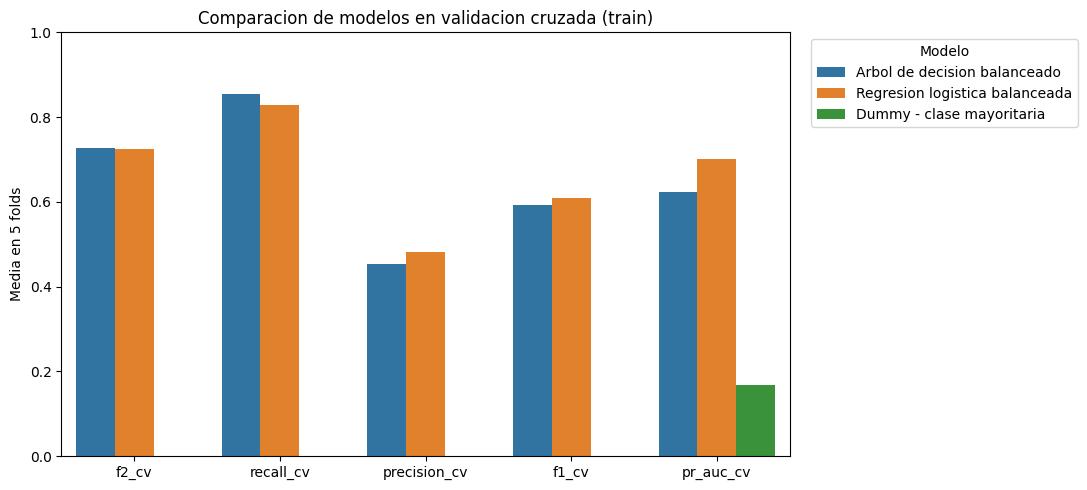

In [12]:
metric_plot = cv_results.melt(
    id_vars="modelo",
    value_vars=["f2_cv", "recall_cv", "precision_cv", "f1_cv", "pr_auc_cv"],
    var_name="metrica",
    value_name="valor",
)

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(
    data=metric_plot,
    x="metrica",
    y="valor",
    hue="modelo",
    ax=ax,
)
ax.set_title("Comparacion de modelos en validacion cruzada (train)")
ax.set_xlabel("")
ax.set_ylabel("Media en 5 folds")
ax.set_ylim(0, 1)
ax.legend(title="Modelo", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

## 9. Matrices de confusion fuera de fold

Para traducir las metricas a cantidades de clientes se generan predicciones **out-of-fold**. Cada cliente de train es predicho por un modelo que no fue entrenado con ese cliente.

Estas matrices todavia no son el resultado final en test, pero permiten entender el costo operativo:

- **verdadero positivo:** cliente con churn correctamente detectado;
- **falso negativo:** cliente que se va y no fue detectado;
- **falso positivo:** alerta sobre un cliente que finalmente no se va;
- **verdadero negativo:** cliente activo correctamente descartado.

,modelo,verdaderos_negativos,falsos_positivos,falsos_negativos,verdaderos_positivos,clientes_contactados,churn_detectado,churn_no_detectado,recall_oof,precision_oof,f2_oof,pr_auc_oof
0,Dummy - clase mayoritaria,3746,0,758,0,0,0,758,0.000,0.000,0.000,0.168
1,Regresion logistica balanceada,3068,678,130,628,1306,628,130,0.828,0.481,0.724,0.697
2,Arbol de decision balanceado,2964,782,110,648,1430,648,110,0.855,0.453,0.726,0.640


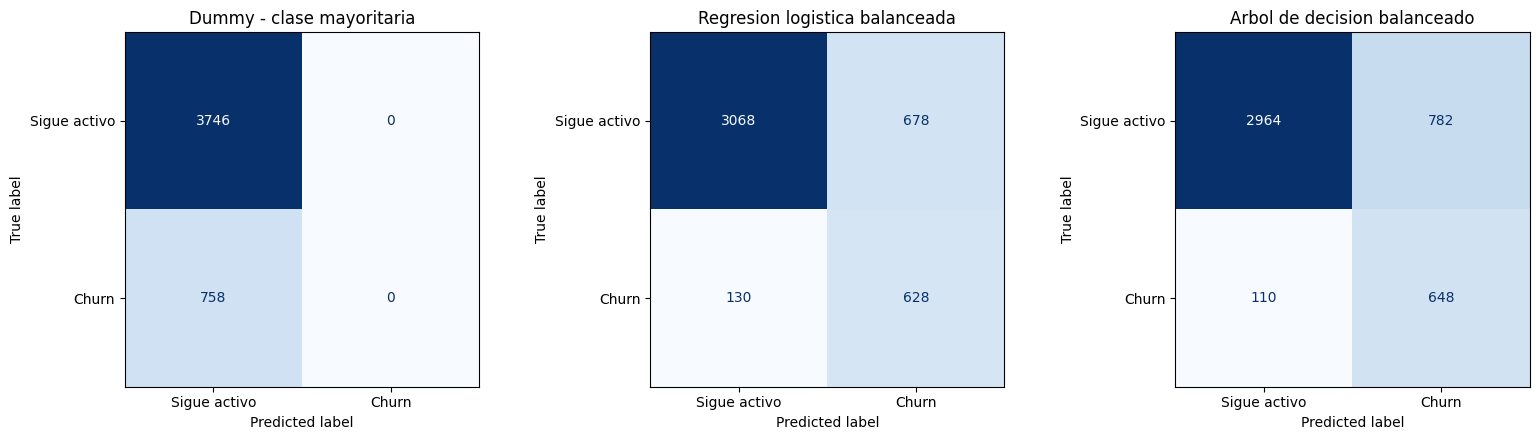

In [13]:
oof_predictions = {}
oof_rows = []

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, (model_name, pipeline) in zip(axes, models.items()):
    predictions = cross_val_predict(
        pipeline,
        X_train_model,
        y_train,
        groups=train_groups,
        cv=cv,
        method="predict",
        n_jobs=1,
    )
    probabilities = cross_val_predict(
        pipeline,
        X_train_model,
        y_train,
        groups=train_groups,
        cv=cv,
        method="predict_proba",
        n_jobs=1,
    )[:, 1]

    oof_predictions[model_name] = {
        "predictions": predictions,
        "probabilities": probabilities,
    }

    tn, fp, fn, tp = confusion_matrix(y_train, predictions).ravel()
    oof_rows.append({
        "modelo": model_name,
        "verdaderos_negativos": tn,
        "falsos_positivos": fp,
        "falsos_negativos": fn,
        "verdaderos_positivos": tp,
        "clientes_contactados": int(fp + tp),
        "churn_detectado": int(tp),
        "churn_no_detectado": int(fn),
        "recall_oof": recall_score(y_train, predictions, zero_division=0),
        "precision_oof": precision_score(y_train, predictions, zero_division=0),
        "f2_oof": fbeta_score(y_train, predictions, beta=2, zero_division=0),
        "pr_auc_oof": average_precision_score(y_train, probabilities),
    })

    ConfusionMatrixDisplay.from_predictions(
        y_train,
        predictions,
        display_labels=["Sigue activo", "Churn"],
        cmap="Blues",
        colorbar=False,
        ax=ax,
    )
    ax.set_title(model_name)

plt.tight_layout()

oof_summary = pd.DataFrame(oof_rows)
display(oof_summary)


## 10. Interpretacion inicial de los modelos

La comparacion se ordena principalmente por F2 y no debe leerse como una competencia por accuracy:

- El **Dummy** muestra cuanto se obtiene sin detectar churn. Si tiene accuracy alta y recall cero, confirma que accuracy no sirve como criterio principal.
- La **regresion logistica balanceada** aumenta el peso de la clase minoritaria. Suele ofrecer buen recall y coeficientes interpretables, a cambio de generar mas alertas.
- El **arbol balanceado** puede capturar interacciones y reglas no lineales. Se limita su profundidad y se exige un minimo de clientes por hoja para reducir sobreajuste y mantenerlo explicable.

En esta etapa no se declara un ganador definitivo: falta comparar el modelo potente, resolver las variables con riesgo temporal y definir cuantos clientes puede contactar el equipo comercial.

,variable,coeficiente,impacto_absoluto
29,categorical__PreferedOrderCat_Others,2.366,2.366
27,categorical__PreferedOrderCat_Laptop & Accessory,-1.762,1.762
0,numeric_knn__Tenure,-1.221,1.221
28,categorical__PreferedOrderCat_Mobile Phone,-0.958,0.958
10,numeric_knn__CashbackAmount,-0.827,0.827
6,numeric_knn__Complain,0.707,0.707
5,numeric_knn__NumberOfAddress,0.664,0.664
11,numeric_knn__OrdersPerTenure,0.559,0.559
18,categorical__PreferredPaymentMode_Cash on Deli...,0.537,0.537
32,categorical__MaritalStatus_Single,0.465,0.465


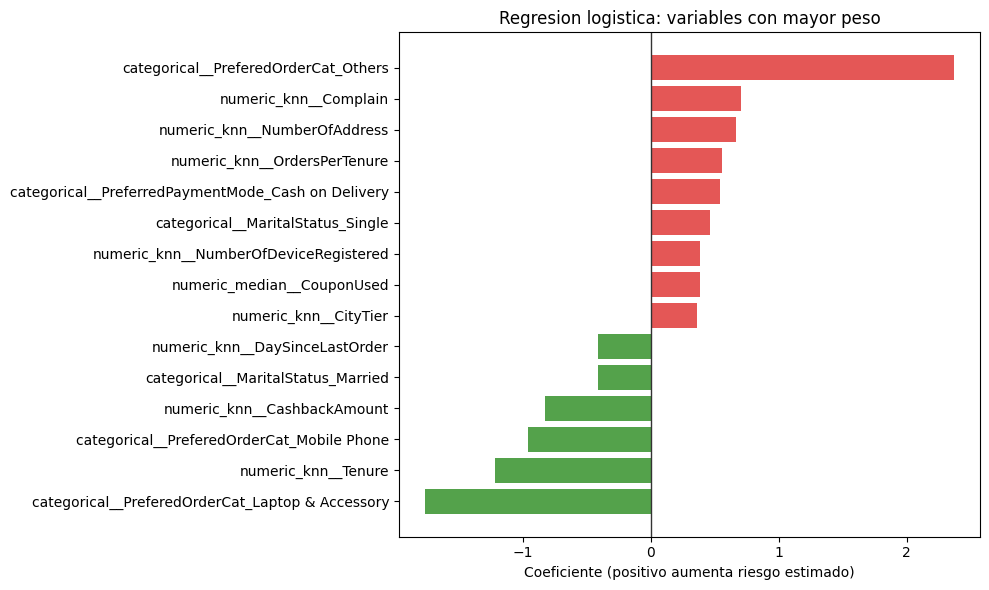

In [14]:
fitted_models = {}
for model_name, pipeline in models.items():
    fitted_models[model_name] = pipeline.fit(X_train_model, y_train)

feature_names_logistic = fitted_models["Regresion logistica balanceada"][
    "preprocessor"
].get_feature_names_out()
logistic_coefficients = fitted_models["Regresion logistica balanceada"][
    "model"
].coef_[0]

logistic_importance = pd.DataFrame({
    "variable": feature_names_logistic,
    "coeficiente": logistic_coefficients,
})
logistic_importance["impacto_absoluto"] = logistic_importance["coeficiente"].abs()
logistic_top = logistic_importance.nlargest(15, "impacto_absoluto").sort_values("coeficiente")

fig, ax = plt.subplots(figsize=(10, 6))
colors = np.where(logistic_top["coeficiente"] > 0, "#E45756", "#54A24B")
ax.barh(logistic_top["variable"], logistic_top["coeficiente"], color=colors)
ax.axvline(0, color="#333333", linewidth=1)
ax.set_title("Regresion logistica: variables con mayor peso")
ax.set_xlabel("Coeficiente (positivo aumenta riesgo estimado)")
ax.set_ylabel("")
plt.tight_layout()

display(logistic_top.sort_values("impacto_absoluto", ascending=False))

,variable,importancia
0,numeric_knn__Tenure,0.634
6,numeric_knn__Complain,0.106
11,numeric_knn__OrdersPerTenure,0.072
4,numeric_knn__SatisfactionScore,0.060
27,categorical__PreferedOrderCat_Laptop & Accessory,0.040
5,numeric_knn__NumberOfAddress,0.021
7,numeric_knn__OrderAmountHikeFromlastYear,0.015
8,numeric_knn__OrderCount,0.015
24,categorical__Gender_Male,0.008
14,numeric_median__WarehouseToHome,0.008


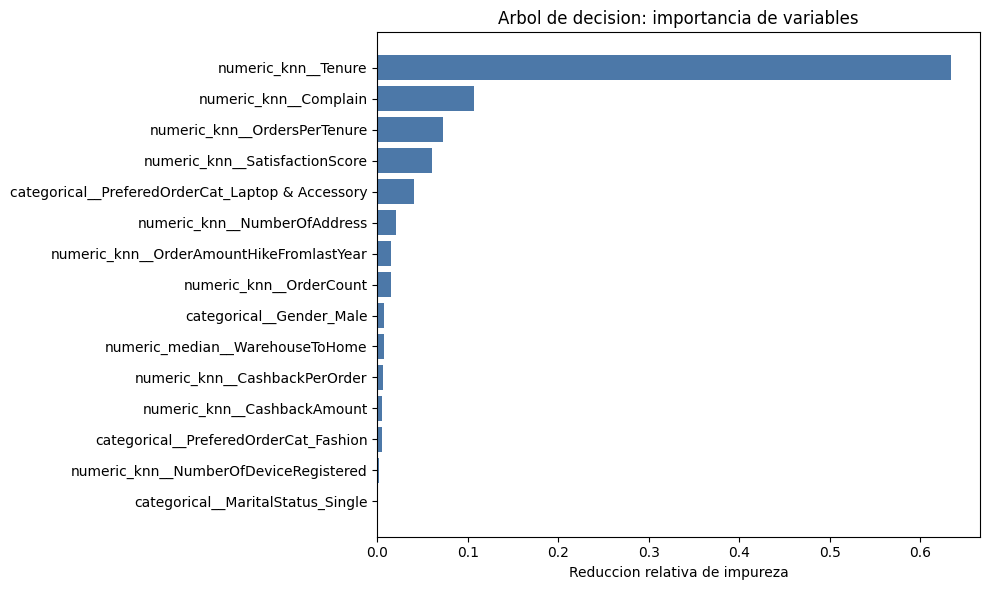

In [15]:
tree_pipeline = fitted_models["Arbol de decision balanceado"]
feature_names_tree = tree_pipeline["preprocessor"].get_feature_names_out()
tree_importances = pd.DataFrame({
    "variable": feature_names_tree,
    "importancia": tree_pipeline["model"].feature_importances_,
}).sort_values("importancia", ascending=False)

tree_top = tree_importances.head(15).sort_values("importancia")

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(tree_top["variable"], tree_top["importancia"], color="#4C78A8")
ax.set_title("Arbol de decision: importancia de variables")
ax.set_xlabel("Reduccion relativa de impureza")
ax.set_ylabel("")
plt.tight_layout()

display(tree_importances.head(15))

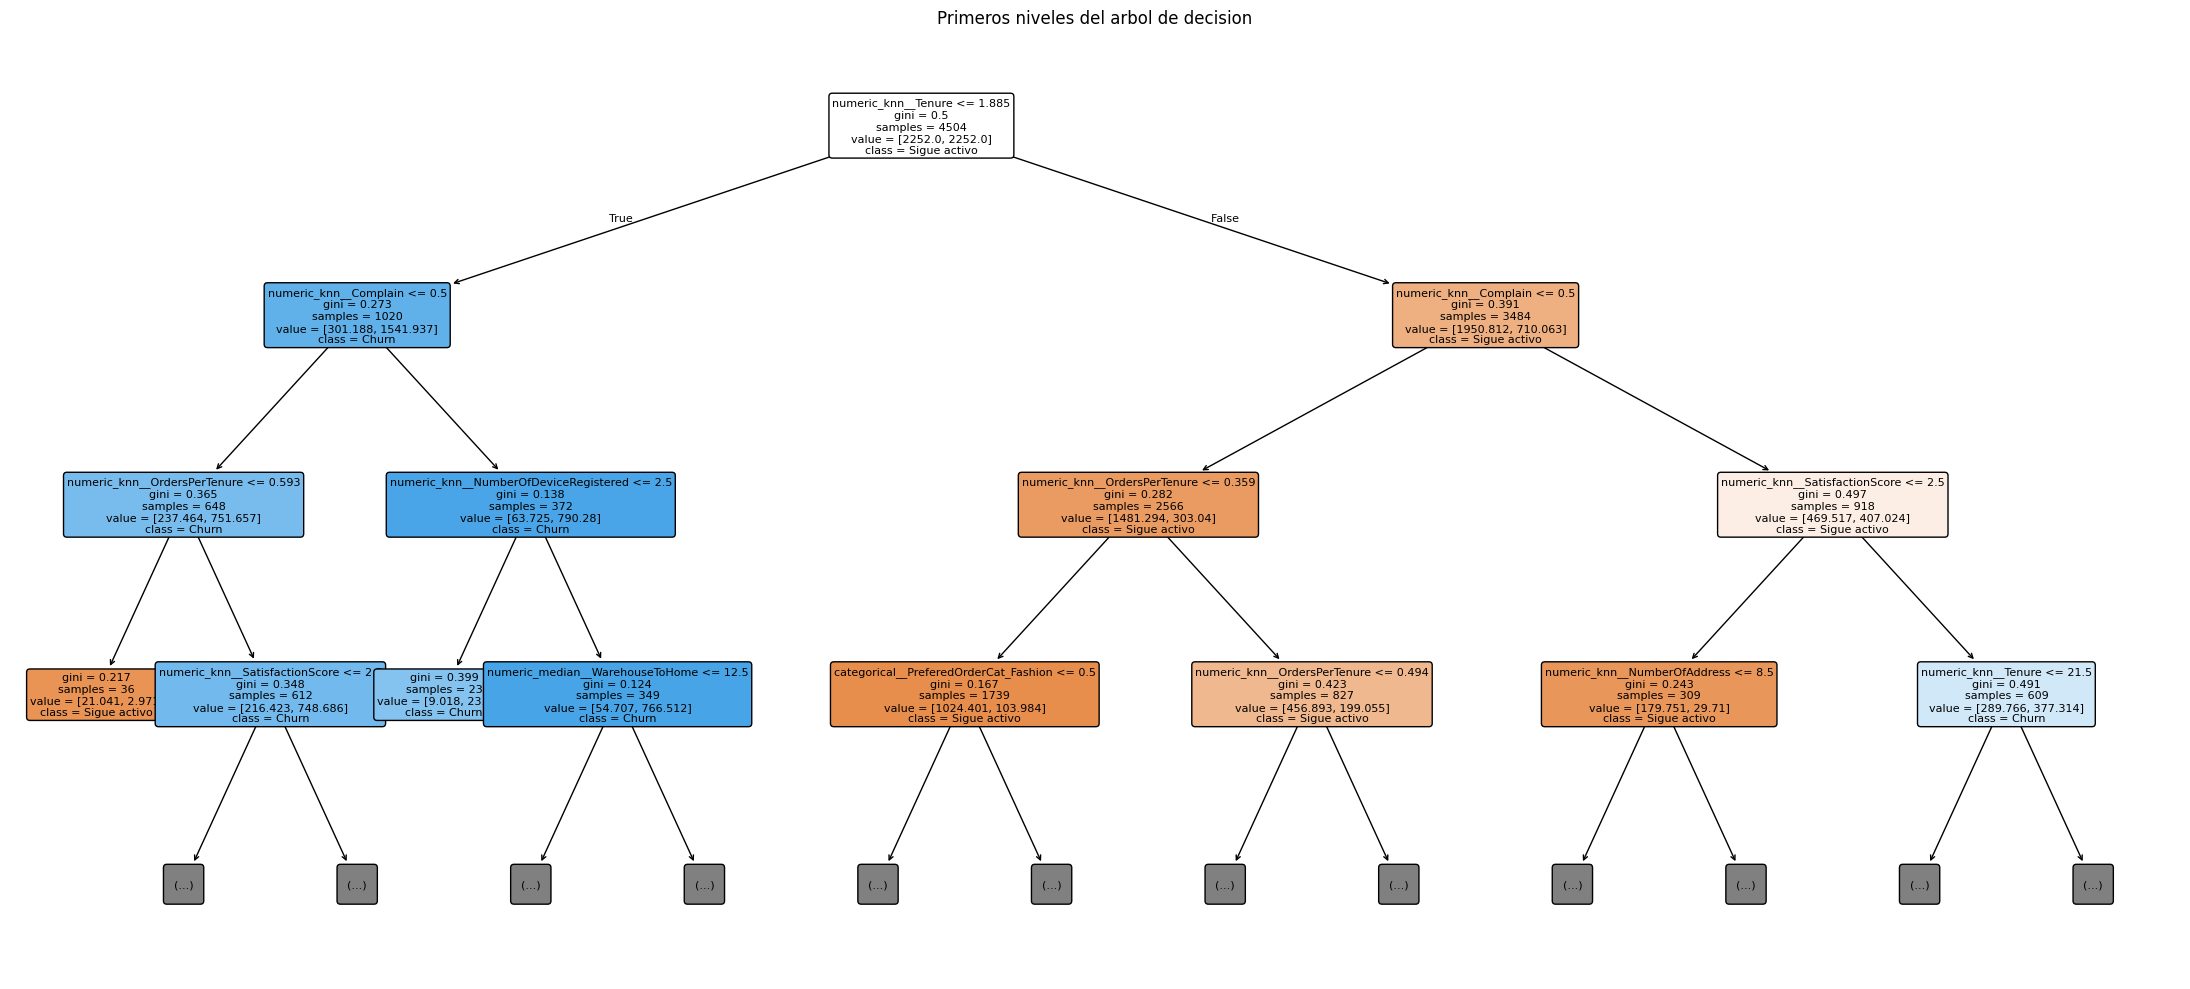

In [16]:
fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    tree_pipeline["model"],
    feature_names=feature_names_tree,
    class_names=["Sigue activo", "Churn"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8,
    ax=ax,
)
ax.set_title("Primeros niveles del arbol de decision")
plt.tight_layout()

## 11. Como leer las explicaciones

**Regresion logistica**

- Un coeficiente positivo aumenta el riesgo estimado de churn.
- Un coeficiente negativo reduce ese riesgo estimado.
- El tamano del coeficiente permite comparar peso dentro del modelo porque las variables numericas fueron estandarizadas.

**Arbol de decision**

- La importancia indica cuanto ayudo una variable a separar clases dentro del arbol.
- Los primeros niveles muestran las reglas que afectan a mas clientes.
- Ni coeficientes ni importancias prueban causalidad. Describen como decide el modelo con estos datos.

Las categorias demograficas deben interpretarse con especial cautela: pueden ayudar a describir segmentos, pero no deberian convertirse por si solas en reglas de trato diferencial.

In [17]:
dummy_row = cv_results.loc[cv_results["modelo"] == "Dummy - clase mayoritaria"].iloc[0]
logistic_row = cv_results.loc[cv_results["modelo"] == "Regresion logistica balanceada"].iloc[0]
tree_row = cv_results.loc[cv_results["modelo"] == "Arbol de decision balanceado"].iloc[0]

print("Lectura automatica de validacion cruzada")
print("-" * 45)
print(
    f"Dummy: accuracy={dummy_row['accuracy_cv']:.3f}, "
    f"recall={dummy_row['recall_cv']:.3f}, "
    f"F2={dummy_row['f2_cv']:.3f}."
)
print(
    f"Logistica: recall={logistic_row['recall_cv']:.3f}, "
    f"precision={logistic_row['precision_cv']:.3f}, "
    f"F2={logistic_row['f2_cv']:.3f}, "
    f"PR-AUC={logistic_row['pr_auc_cv']:.3f}."
)
print(
    f"Arbol: recall={tree_row['recall_cv']:.3f}, "
    f"precision={tree_row['precision_cv']:.3f}, "
    f"F2={tree_row['f2_cv']:.3f}, "
    f"PR-AUC={tree_row['pr_auc_cv']:.3f}."
)
print(
    f"Gap F2 train-CV del arbol: "
    f"{tree_row['f2_train'] - tree_row['f2_cv']:.3f}."
)
print("El conjunto de test no fue utilizado.")

Lectura automatica de validacion cruzada
---------------------------------------------
Dummy: accuracy=0.832, recall=0.000, F2=0.000.
Logistica: recall=0.828, precision=0.482, F2=0.724, PR-AUC=0.700.
Arbol: recall=0.855, precision=0.453, F2=0.726, PR-AUC=0.623.
Gap F2 train-CV del arbol: 0.026.
El conjunto de test no fue utilizado.


## 12. Ajuste del umbral sin tocar test

El umbral estandar de 0,50 no tiene por que ser el mejor para el negocio. Se evaluan umbrales entre 0,20 y 0,80 usando exclusivamente probabilidades fuera de fold de train.

Para cada umbral se calcula:

- F2, metrica principal;
- recall y precision;
- cantidad de clientes que recibirian una alerta;
- churn detectado y no detectado;
- falsas alertas.

El umbral provisorio de cada modelo es el que maximiza F2. Esta optimizacion no usa test y no constituye todavia una decision operativa final: el umbral tambien debe respetar presupuesto y capacidad de contacto.

In [18]:
thresholds = np.round(np.arange(0.20, 0.81, 0.01), 2)
threshold_rows = []

candidate_models = [
    "Regresion logistica balanceada",
    "Arbol de decision balanceado",
]

for model_name in candidate_models:
    probabilities = oof_predictions[model_name]["probabilities"]

    for threshold in thresholds:
        predictions = (probabilities >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_train, predictions).ravel()

        threshold_rows.append({
            "modelo": model_name,
            "umbral": threshold,
            "f2": fbeta_score(y_train, predictions, beta=2, zero_division=0),
            "recall": recall_score(y_train, predictions, zero_division=0),
            "precision": precision_score(y_train, predictions, zero_division=0),
            "clientes_contactados": int(tp + fp),
            "churn_detectado": int(tp),
            "churn_no_detectado": int(fn),
            "falsas_alertas": int(fp),
        })

threshold_results = pd.DataFrame(threshold_rows)

best_thresholds = (
    threshold_results
    .sort_values(
        ["modelo", "f2", "precision", "umbral"],
        ascending=[True, False, False, False],
    )
    .groupby("modelo", as_index=False)
    .first()
    .sort_values("f2", ascending=False)
)

display(best_thresholds.round({
    "umbral": 2,
    "f2": 3,
    "recall": 3,
    "precision": 3,
}))


,modelo,umbral,f2,recall,precision,clientes_contactados,churn_detectado,churn_no_detectado,falsas_alertas
0,Arbol de decision balanceado,0.410,0.734,0.876,0.444,1494,664,94,830
1,Regresion logistica balanceada,0.490,0.729,0.839,0.478,1331,636,122,695


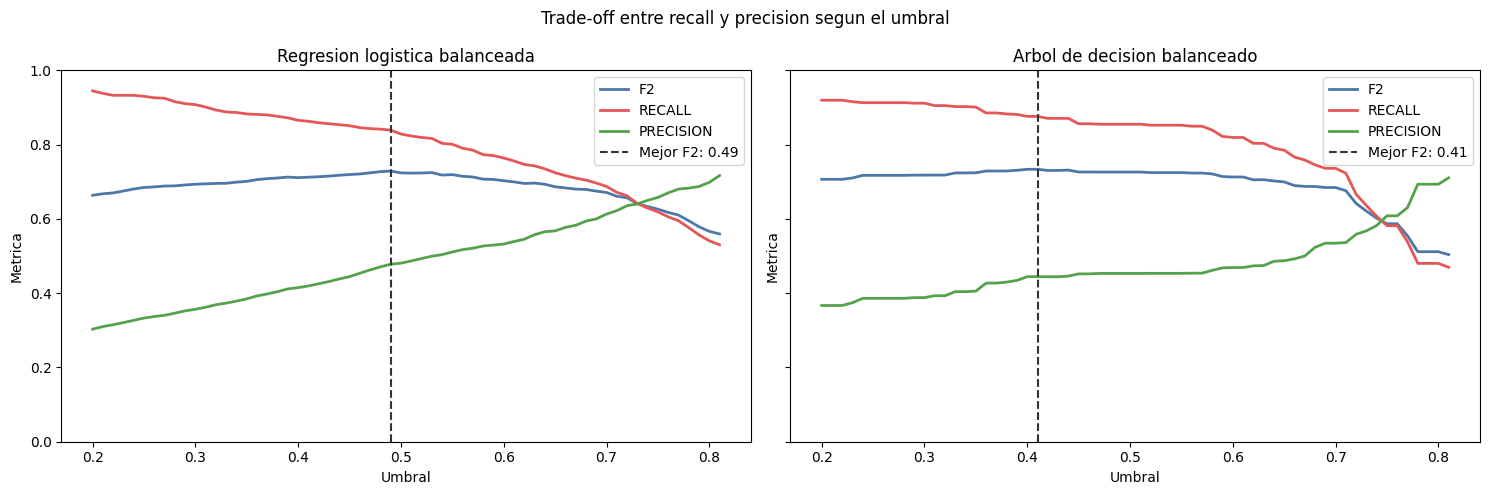

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

for ax, model_name in zip(axes, candidate_models):
    model_thresholds = threshold_results[threshold_results["modelo"] == model_name]
    best_row = best_thresholds[best_thresholds["modelo"] == model_name].iloc[0]

    for metric, color in [
        ("f2", "#4C78A8"),
        ("recall", "#E45756"),
        ("precision", "#54A24B"),
    ]:
        ax.plot(
            model_thresholds["umbral"],
            model_thresholds[metric],
            label=metric.upper(),
            color=color,
            linewidth=2,
        )

    ax.axvline(
        best_row["umbral"],
        color="#333333",
        linestyle="--",
        label=f"Mejor F2: {best_row['umbral']:.2f}",
    )
    ax.set_title(model_name)
    ax.set_xlabel("Umbral")
    ax.set_ylabel("Metrica")
    ax.set_ylim(0, 1)
    ax.legend()

plt.suptitle("Trade-off entre recall y precision segun el umbral")
plt.tight_layout()


In [20]:
reference_thresholds = []

for model_name in candidate_models:
    model_thresholds = threshold_results[threshold_results["modelo"] == model_name]
    best_threshold = best_thresholds.loc[
        best_thresholds["modelo"] == model_name, "umbral"
    ].iloc[0]

    selected = model_thresholds[
        model_thresholds["umbral"].isin(
            sorted(set([0.40, 0.50, 0.60, float(best_threshold)]))
        )
    ].copy()
    reference_thresholds.append(selected)

threshold_comparison = (
    pd.concat(reference_thresholds, ignore_index=True)
    .sort_values(["modelo", "umbral"])
)

display(threshold_comparison.round({
    "umbral": 2,
    "f2": 3,
    "recall": 3,
    "precision": 3,
}))


,modelo,umbral,f2,recall,precision,clientes_contactados,churn_detectado,churn_no_detectado,falsas_alertas
4,Arbol de decision balanceado,0.400,0.734,0.876,0.444,1494,664,94,830
5,Arbol de decision balanceado,0.410,0.734,0.876,0.444,1494,664,94,830
6,Arbol de decision balanceado,0.500,0.726,0.855,0.453,1430,648,110,782
7,Arbol de decision balanceado,0.600,0.713,0.819,0.469,1324,621,137,703
0,Regresion logistica balanceada,0.400,0.711,0.865,0.415,1581,656,102,925
1,Regresion logistica balanceada,0.490,0.729,0.839,0.478,1331,636,122,695
2,Regresion logistica balanceada,0.500,0.724,0.828,0.481,1306,628,130,678
3,Regresion logistica balanceada,0.600,0.703,0.764,0.532,1088,579,179,509


### Resultado intermedio del ajuste

Este bloque corresponde a la comparacion inicial de regresion logistica y arbol con las variables disponibles. Sirvio para entender el trade-off entre recall, precision y cantidad de contactos.

No representa la decision final porque posteriormente se:

1. detectaron perfiles duplicados;
2. cambio la validacion a grupos;
3. incorporo Random Forest;
4. excluyeron `Complain` y `DaySinceLastOrder` por temporalidad no confirmada;
5. selecciono el umbral definitivo antes de abrir test.

La decision final se presenta en las secciones siguientes.


## 12 bis. Busqueda de hiperparametros y seleccion final

Las secciones anteriores compararon modelos con hiperparametros elegidos a mano.
Aca se elige cada configuracion de forma **sistematica y reproducible** con
`GridSearchCV`, usando la **misma validacion cruzada agrupada** y la **misma
metrica F2**. Todo ocurre dentro de train; test sigue cerrado.

Ademas se responde de frente la pregunta del negocio: **la precision de 36,5%
del cierre anterior no fue un defecto, fue una consecuencia de priorizar recall**
(metrica F2 + umbral bajo + eleccion de la regresion logistica). Precision y
recall se contraponen: subir una baja la otra, *salvo* que el modelo ordene mejor
el riesgo (mayor PR-AUC). Para verlo sin trampa se compara a **igual recall**:
fijando el mismo nivel de deteccion (~84%), gana el modelo que genera **menos
falsas alertas** (mas precision).

In [21]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path("tools").resolve()))
from finalize_modeling import (
    build_preprocessor,
    prepare_features,
    metrics_from_probabilities,
    precision_at_recall,
    SUSPICIOUS_FEATURES,
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Escenario conservador: mismas variables que el modelo final
# (sin Complain ni DaySinceLastOrder, por temporalidad no confirmada).
X_train_tuned = prepare_features(X_train, SUSPICIOUS_FEATURES)

f2_scorer = make_scorer(fbeta_score, beta=2, zero_division=0)
prep_scaled = build_preprocessor(X_train_tuned, scale_numeric=True)
prep_plain = build_preprocessor(X_train_tuned, scale_numeric=False)

# Grillas chicas y explicables (que se probo y por que gano cada modelo).
search_spaces = {
    "Regresion logistica": (
        Pipeline([
            ("preprocessor", prep_scaled),
            ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
        ]),
        {
            "model__C": [0.1, 1.0, 10.0],
            "model__class_weight": ["balanced", {0: 1, 1: 3}],
        },
    ),
    "Arbol de decision": (
        Pipeline([
            ("preprocessor", prep_plain),
            ("model", DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE)),
        ]),
        {
            "model__max_depth": [4, 5, 6],
            "model__min_samples_leaf": [20, 40],
        },
    ),
    "Random Forest": (
        Pipeline([
            ("preprocessor", prep_plain),
            ("model", RandomForestClassifier(
                max_features=0.5, max_samples=0.7,
                random_state=RANDOM_STATE, n_jobs=-1,
            )),
        ]),
        {
            "model__n_estimators": [300, 500],
            "model__max_depth": [12, 16],
            "model__min_samples_leaf": [4, 8],
            "model__class_weight": ["balanced", {0: 1, 1: 5}],
        },
    ),
}

tuned_oof = {}
search_summary = []
for name, (pipeline, grid) in search_spaces.items():
    search = GridSearchCV(pipeline, grid, scoring=f2_scorer, cv=cv, n_jobs=-1, refit=True)
    search.fit(X_train_tuned, y_train, groups=train_groups)
    tuned_oof[name] = cross_val_predict(
        search.best_estimator_, X_train_tuned, y_train,
        cv=cv, groups=train_groups, method="predict_proba", n_jobs=-1,
    )[:, 1]
    best_params = {k.replace("model__", ""): v for k, v in search.best_params_.items()}
    search_summary.append({
        "modelo": name,
        "F2_CV": round(search.best_score_, 3),
        "mejores_hiperparametros": best_params,
    })

display(pd.DataFrame(search_summary))

C:\Users\ftamaki\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,modelo,F2_CV,mejores_hiperparametros
0,Regresion logistica,0.689,"{'C': 0.1, 'class_weight': 'balanced'}"
1,Arbol de decision,0.668,"{'max_depth': 6, 'min_samples_leaf': 20}"
2,Random Forest,0.697,"{'class_weight': {0: 1, 1: 5}, 'max_depth': 12..."


In [22]:
TARGET_RECALL = 0.84  # nivel de deteccion actual que se quiere mantener

iso_rows = []
for name, probs in tuned_oof.items():
    at_050 = metrics_from_probabilities(y_train, probs, 0.50)
    iso = precision_at_recall(y_train, probs, TARGET_RECALL)
    iso_rows.append({
        "modelo": name,
        "F2@0.50": round(at_050["f2"], 3),
        "recall@0.50": round(at_050["recall"], 3),
        "precision@0.50": round(at_050["precision"], 3),
        "PR_AUC": round(at_050["pr_auc"], 3),
        "recall_iso": round(iso["recall"], 3),
        "precision_iso": round(iso["precision"], 3),
        "contactos_iso": iso["contacts"],
        "falsas_alertas_iso": iso["fp"],
    })

iso_table = pd.DataFrame(iso_rows)
display(iso_table)

best_iso = iso_table.sort_values("precision_iso", ascending=False).iloc[0]
worst_iso = iso_table.sort_values("precision_iso").iloc[0]
print(
    f"A igual recall (~{TARGET_RECALL:.0%}), el modelo con mas precision es "
    f"{best_iso['modelo']}: precision={best_iso['precision_iso']:.3f} con solo "
    f"{int(best_iso['falsas_alertas_iso'])} falsas alertas, frente a "
    f"{int(worst_iso['falsas_alertas_iso'])} del peor. Misma deteccion, "
    f"casi la mitad de alertas equivocadas."
)
print(
    "El Random Forest tambien tiene el F2 mas alto a umbral 0,50, por lo que el "
    "criterio recall-first lo selecciona como modelo final (ver secciones siguientes)."
)

,modelo,F2@0.50,recall@0.50,precision@0.50,PR_AUC,recall_iso,precision_iso,contactos_iso,falsas_alertas_iso
0,Regresion logistica,0.688,0.809,0.431,0.609,0.842,0.400,1596,958
1,Arbol de decision,0.669,0.780,0.427,0.579,0.854,0.351,1844,1197
2,Random Forest,0.698,0.707,0.662,0.768,0.843,0.573,1116,477


A igual recall (~84%), el modelo con mas precision es Random Forest: precision=0.573 con solo 477 falsas alertas, frente a 1197 del peor. Misma deteccion, casi la mitad de alertas equivocadas.
El Random Forest tambien tiene el F2 mas alto a umbral 0,50, por lo que el criterio recall-first lo selecciona como modelo final (ver secciones siguientes).


## 13. Conclusion final

El **Random Forest tuneado** fue elegido como modelo final bajo el escenario
conservador sin `Complain` ni `DaySinceLastOrder`. Reemplaza a la regresion
logistica del cierre anterior: con hiperparametros elegidos por `GridSearchCV`,
ordena mejor el riesgo (mayor PR-AUC) y, **al mismo nivel de recall, genera la
mitad de falsas alertas**.

### Por que sube la precision sin resignar recall

La precision de 36,5% del cierre previo era consecuencia de priorizar recall con
un modelo que ordenaba peor el riesgo. El Random Forest mejora la **capacidad de
ordenar** (PR-AUC fuera de fold 0,77 vs 0,61 de la logistica), asi que el mismo
recall se consigue con un umbral que deja afuera muchas menos falsas alertas.

### Seleccion dentro de train

- Validacion: `StratifiedGroupKFold` con 5 folds.
- Metrica principal: F2 con `beta=2`.
- Hiperparametros: elegidos por `GridSearchCV` (seccion 12 bis).
- Umbral elegido fuera de fold: `0.27`.
- F2 fuera de fold: `0.797`.
- Recall fuera de fold: `90.6%`.
- Precision fuera de fold: `53.7%`.

### Evaluacion final en test

- F2: `0.817`.
- Recall: `91.1%`.
- Precision: `57.9%`.
- PR-AUC: `0.834`.
- ROC-AUC: `0.955`.
- Churn detectado: `173` de `190`.
- Falsas alertas: `126`.
- Clientes priorizados: `299` de `1126`.

Comparado de forma justa sobre el mismo split, la logistica anterior daba en test
recall 84,2% con precision 40,7% y 233 falsas alertas. El Random Forest sube el
recall a 91,1% y la precision a 57,9%, casi **dividiendo a la mitad** las falsas
alertas. La precision sigue lejos del 100% porque el churn es minoritario (~17%)
y se prioriza detectar: es un punto de operacion elegido, no un fracaso.

> Nota de reproducibilidad: los conteos exactos de test dependen levemente de la
> version de scikit-learn por el barajado de `StratifiedGroupKFold`. Para
> reproducir identico, usar las versiones fijadas en `requirements.txt`.

Las importancias por permutacion describen como decide el modelo; no prueban
causalidad.

In [23]:
from pathlib import Path
import json

FINAL_RESULTS_PATH = Path("reports/final_modeling_results.json")
assert FINAL_RESULTS_PATH.exists()

final_results = json.loads(FINAL_RESULTS_PATH.read_text(encoding="utf-8"))
assert final_results["shared_profile_groups_train_test"] == 0
assert final_results["selected_model"] == "Random Forest"
assert final_results["protocol"]["selection_metric"] == "F2 beta=2"
assert final_results["protocol"]["test_used_for_selection"] is False
assert final_results["protocol"]["test_evaluation_frozen"] is True

print("Validaciones finales OK")
print("Modelo final:", final_results["selected_model"])
print("Umbral final:", final_results["selected_threshold_oof"]["threshold"])
print("Test congelado:", final_results["final_test_rows"], "clientes")


Validaciones finales OK
Modelo final: Random Forest
Umbral final: 0.27
Test congelado: 1126 clientes



## 14. Comparacion final y sensibilidad temporal

Los resultados siguientes se cargan desde `reports/final_modeling_results.json`, generado por `tools/finalize_modeling.py`. El script tiene una proteccion para no reabrir test accidentalmente.


,model,f2,recall,precision,pr_auc,roc_auc,contacts
0,Dummy,0.000,0.000,0.000,0.168,0.500,0
1,Regresion logistica,0.688,0.809,0.431,0.609,0.868,1421
2,Arbol de decision,0.669,0.780,0.427,0.579,0.855,1383
3,Random Forest,0.698,0.707,0.662,0.768,0.936,810


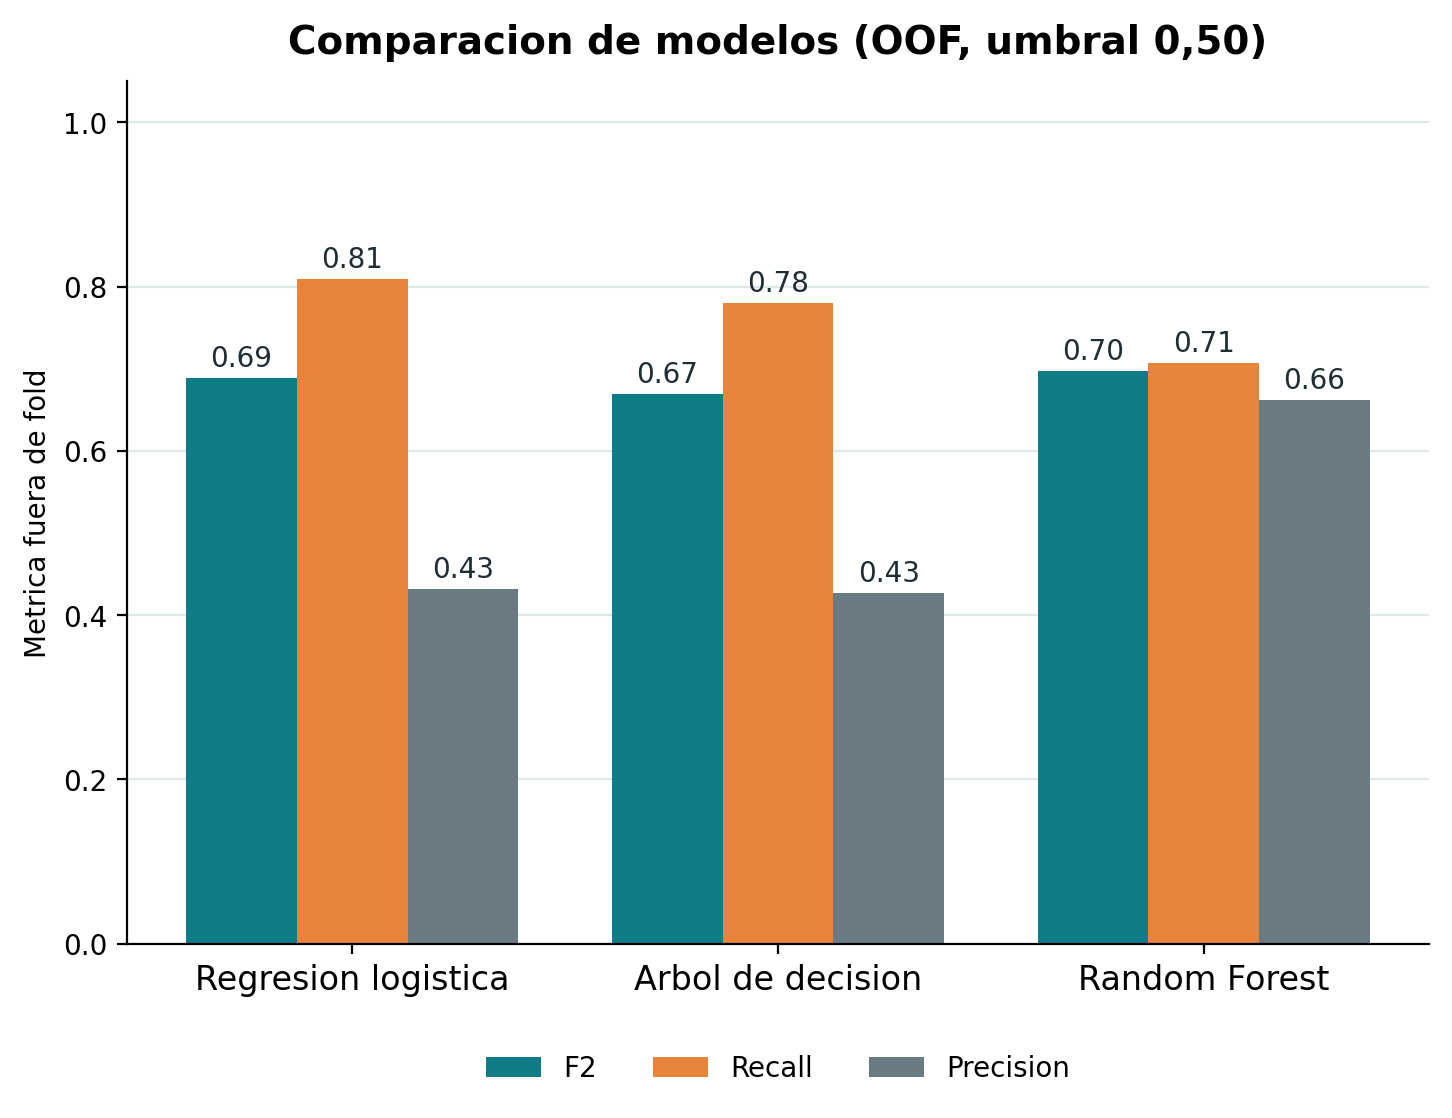

,scenario,f2,recall,precision,pr_auc,roc_auc
0,Completo,0.763,0.768,0.743,0.830,0.957
1,Sin Complain,0.699,0.703,0.683,0.784,0.942
2,Sin DaySinceLastOrder,0.759,0.765,0.737,0.821,0.954
3,Conservador: sin ambas,0.698,0.707,0.662,0.768,0.936


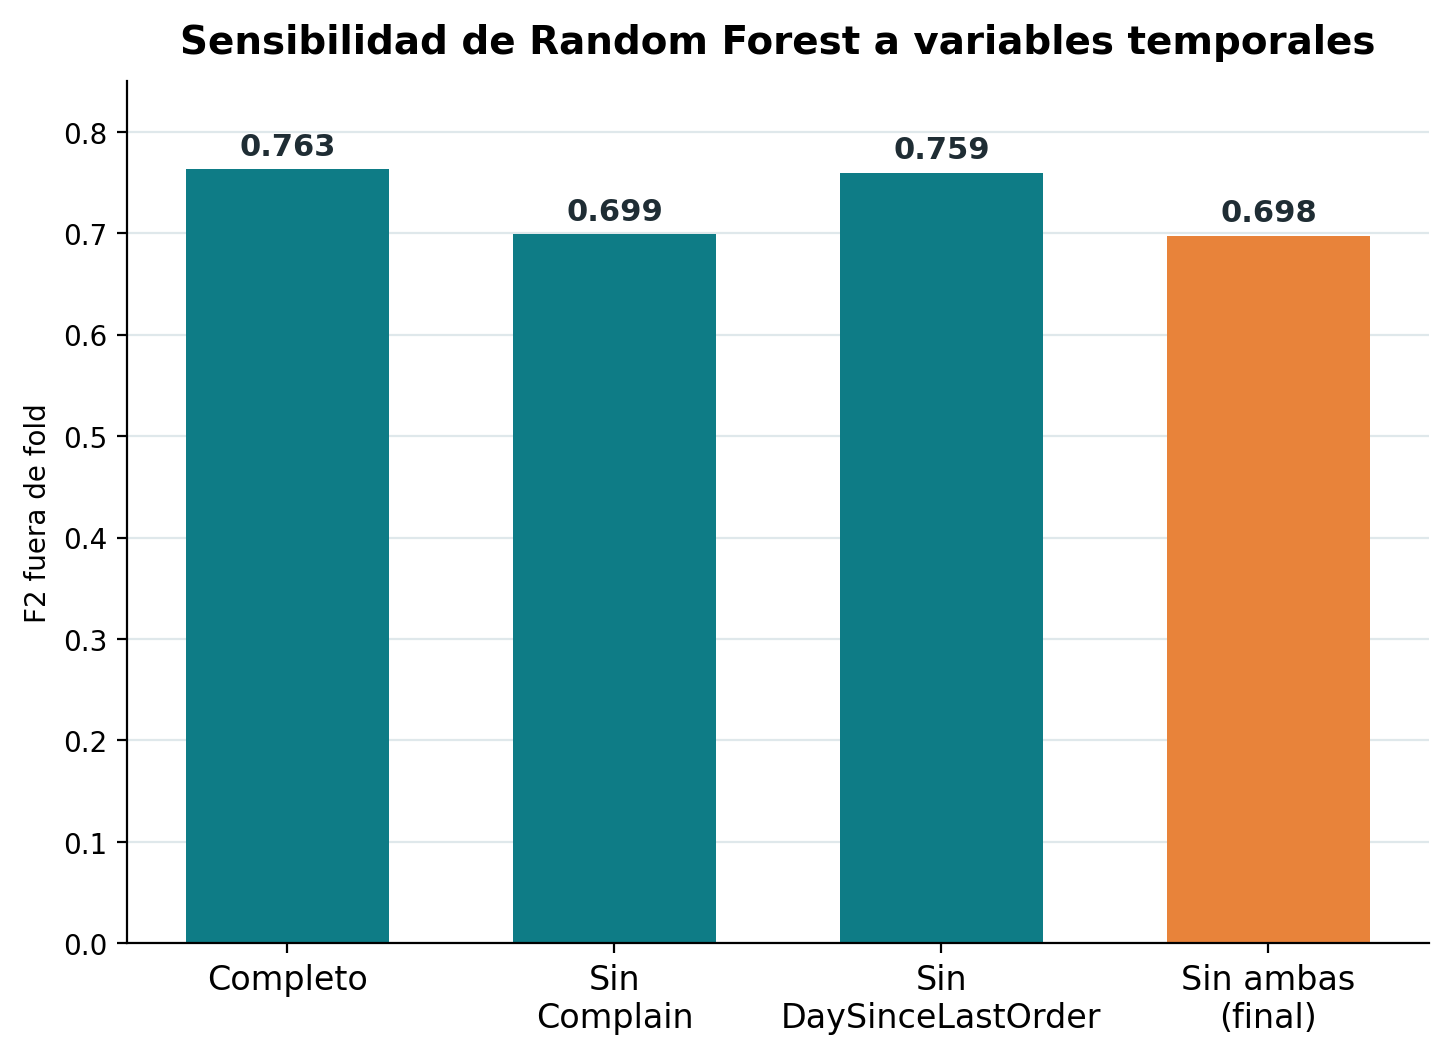

In [24]:

from IPython.display import Image, display

model_comparison = pd.DataFrame(
    final_results["model_comparison_oof_threshold_050"]
)[["model", "f2", "recall", "precision", "pr_auc", "roc_auc", "contacts"]]

temporal_sensitivity = pd.DataFrame(
    final_results["temporal_sensitivity_rf_threshold_050"]
)[["scenario", "f2", "recall", "precision", "pr_auc", "roc_auc"]]

display(model_comparison.round(3))
display(Image(filename="reports/figures/final_model_comparison_cv.png"))
display(temporal_sensitivity.round(3))
display(Image(filename="reports/figures/temporal_sensitivity_f2.png"))



## 15. Evaluacion final en test

El umbral se eligio exclusivamente con probabilidades fuera de fold de train. Despues de congelar modelo, variables y umbral, test se utilizo para una unica evaluacion final.


,threshold,f2,recall,precision,f1,pr_auc,roc_auc,accuracy,contacts,tp,fp,fn,tn
0,0.270,0.817,0.911,0.579,0.708,0.834,0.955,0.873,299,173,126,17,810


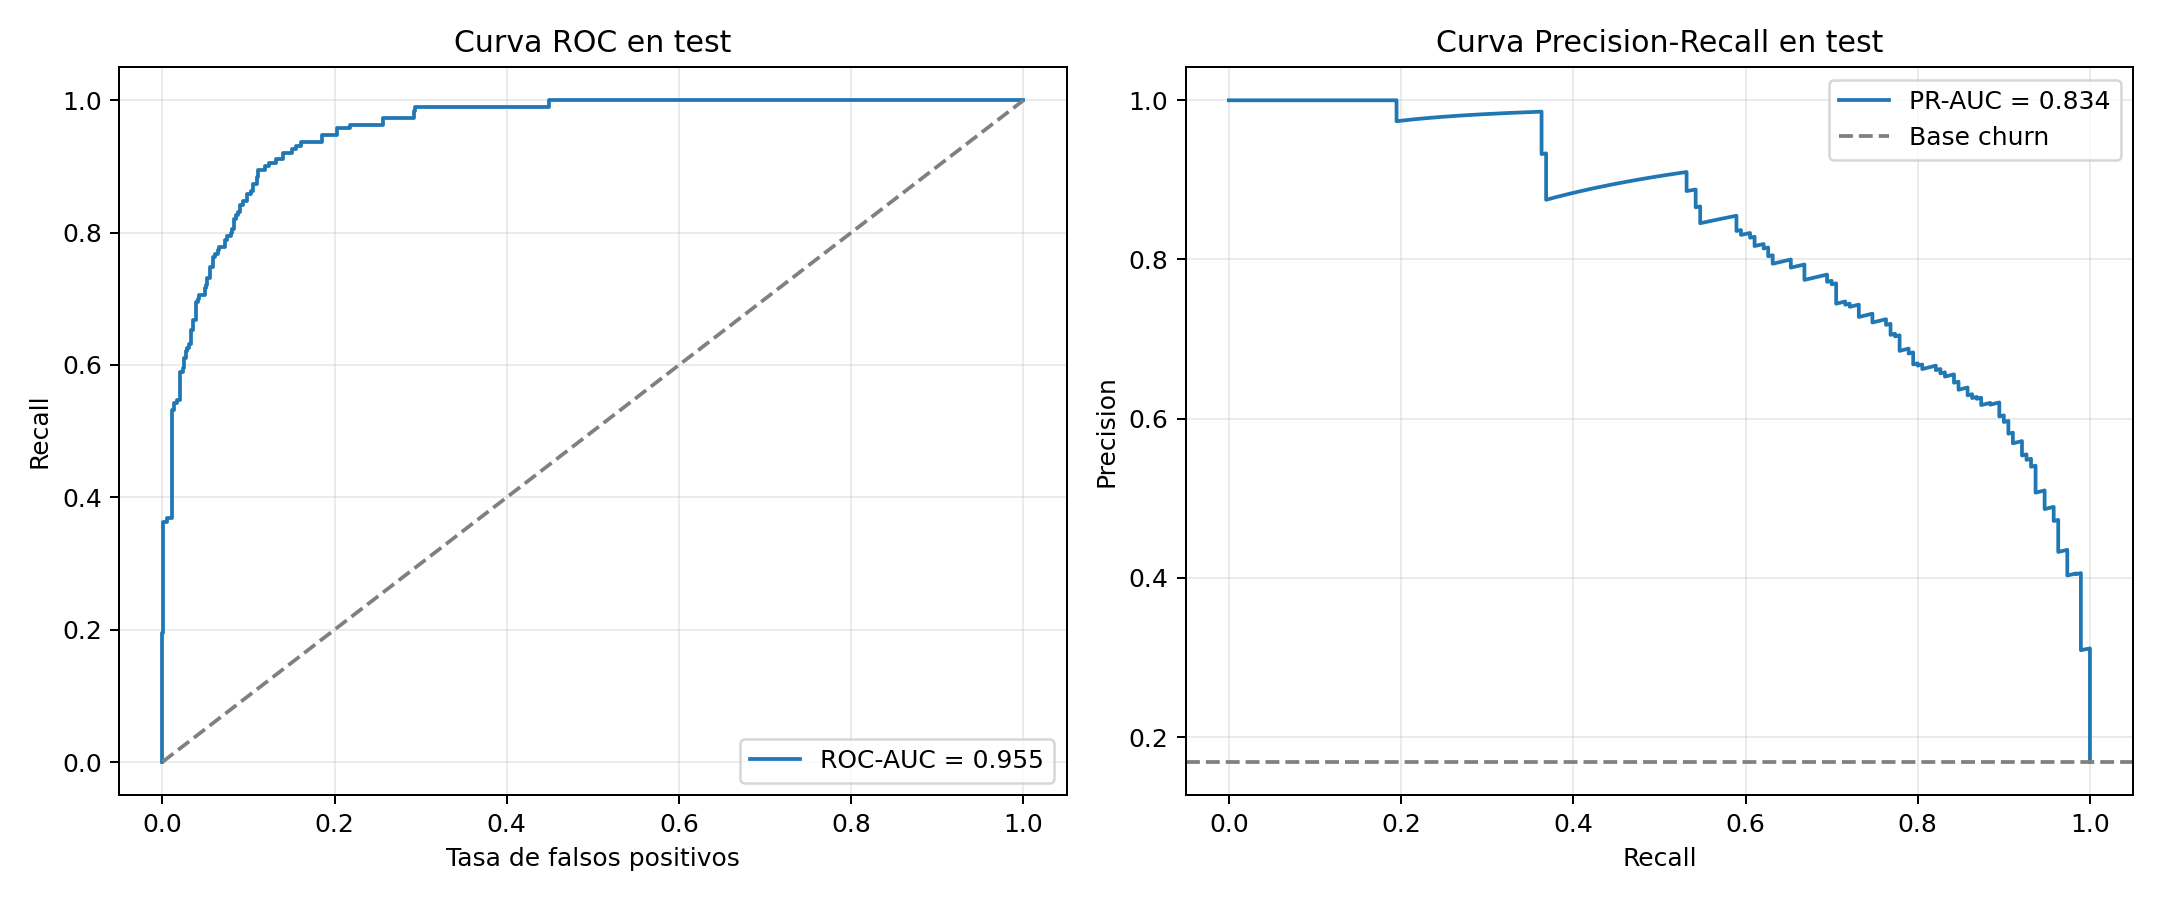

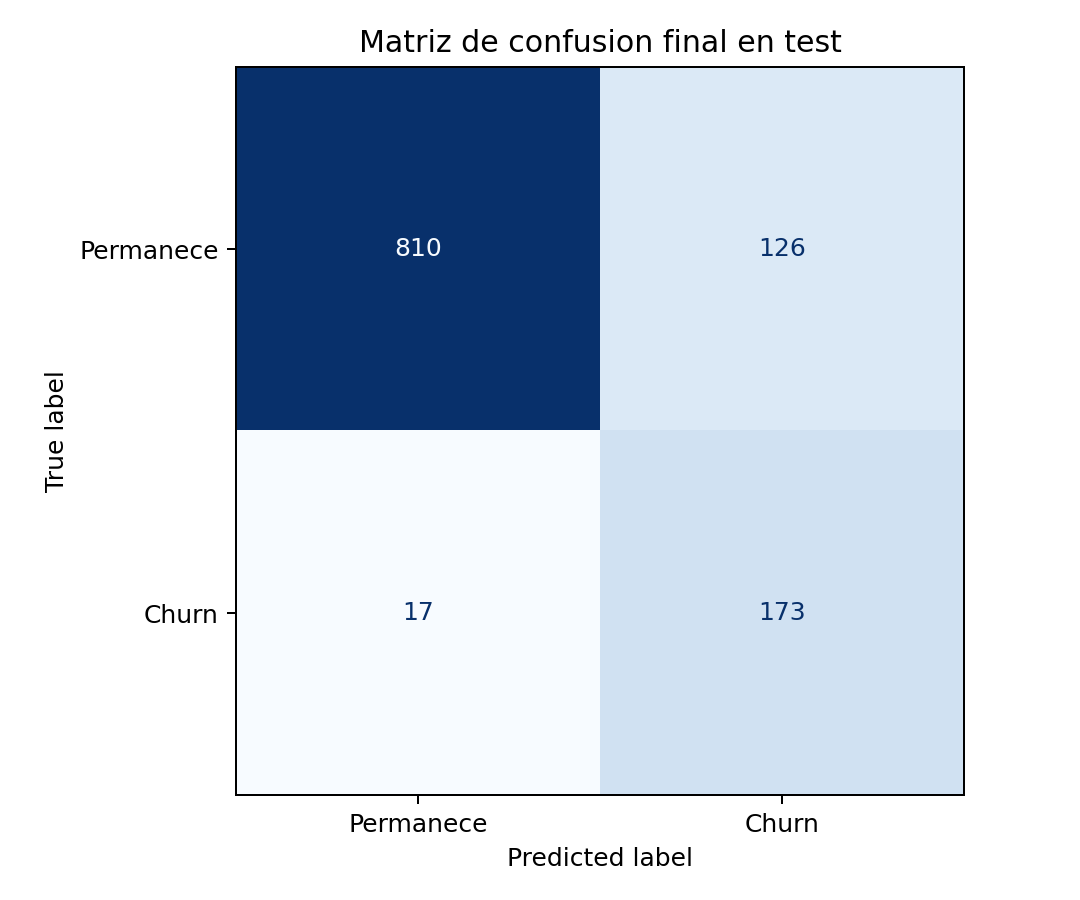

In [25]:

test_metrics = pd.DataFrame([final_results["final_test_metrics"]])
display(test_metrics.round(3))
display(Image(filename="reports/figures/final_test_roc_pr.png"))
display(Image(filename="reports/figures/final_test_confusion_matrix.png"))


## 16. Interpretabilidad sin dependencias extra

- La **importancia por permutacion** mide cuanto cae F2 cuando se desordena una
  variable. Se calcula sobre test con el modelo final y se regenera junto con el
  resto de los artefactos.
- Las explicaciones SHAP son **opcionales**: requieren `pip install shap`. Si la
  libreria esta instalada, `tools/finalize_modeling.py` tambien genera SHAP
  global y local; si no, se omiten sin romper el cierre.

Estas tecnicas explican el comportamiento del modelo, no relaciones causales.

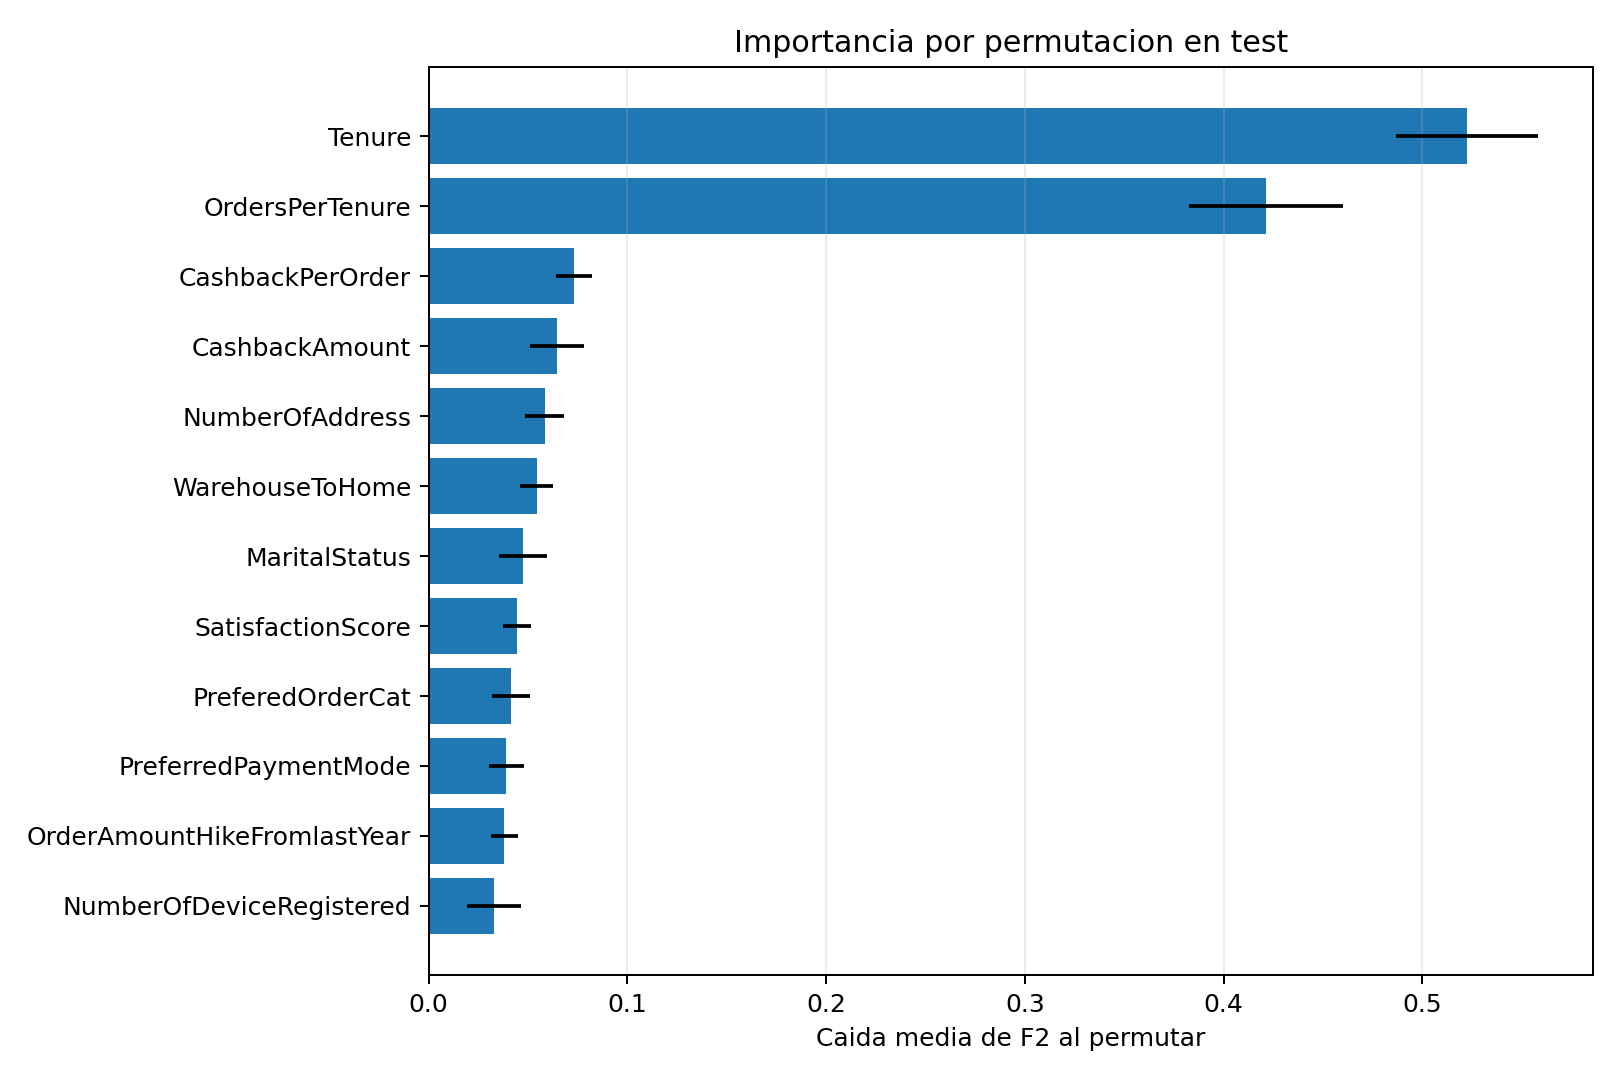

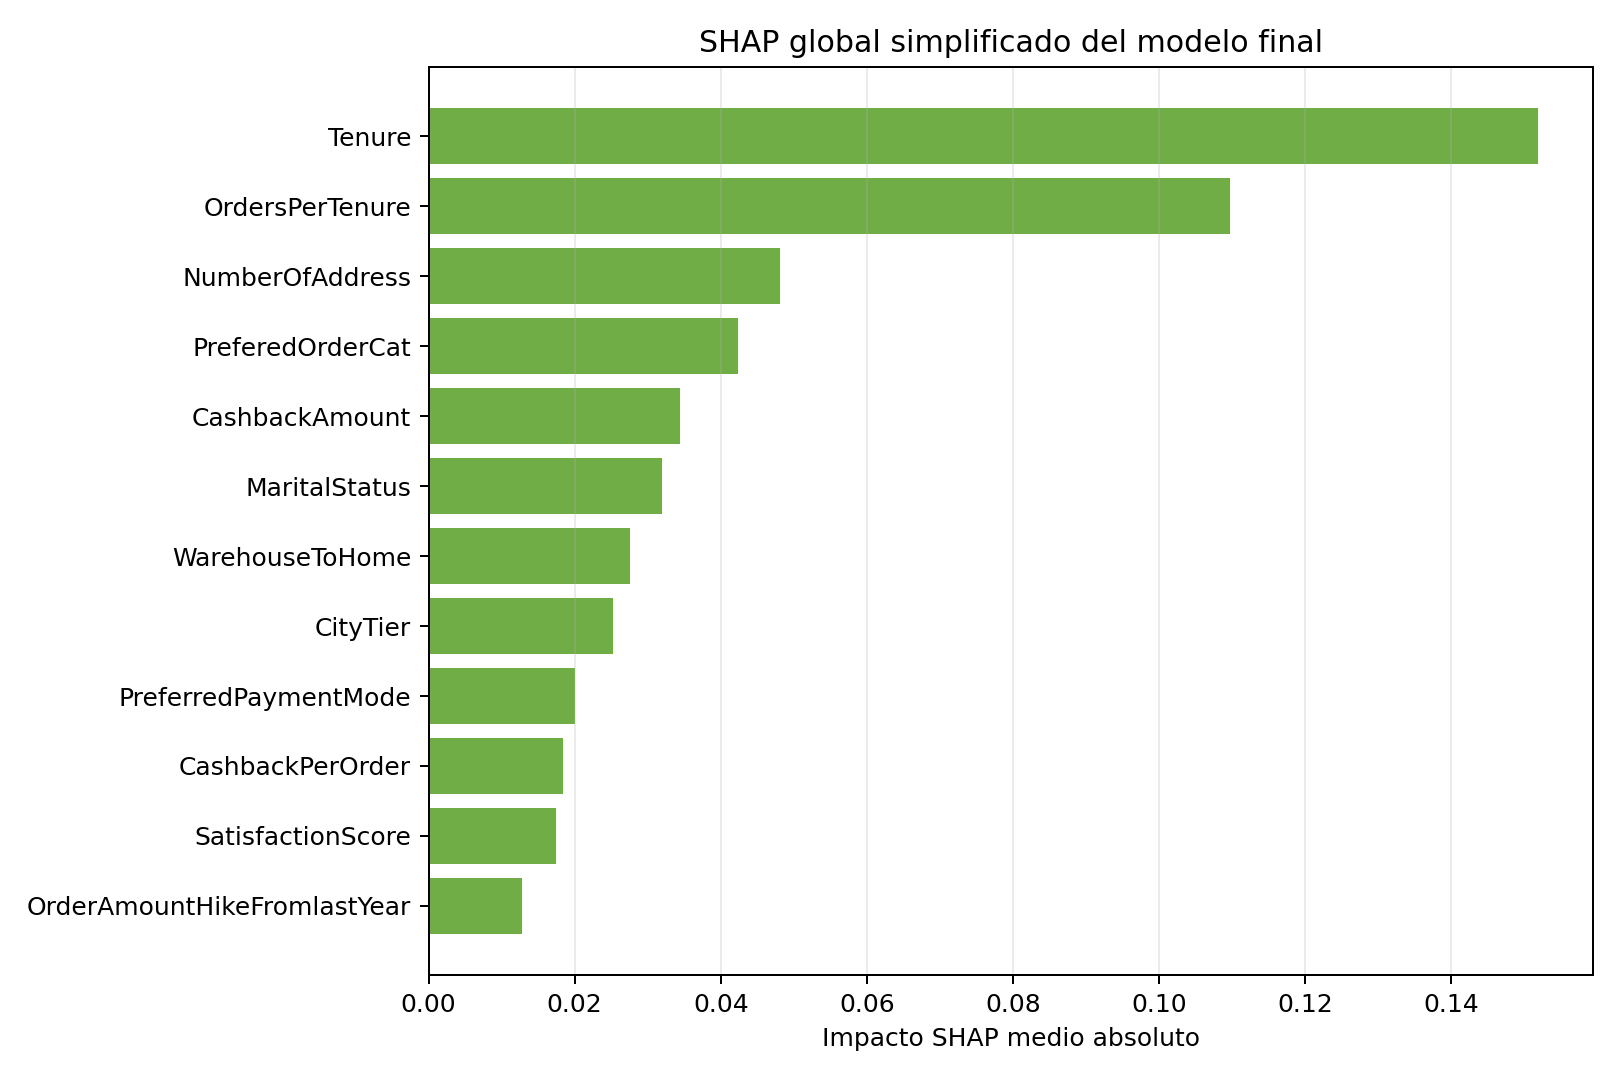

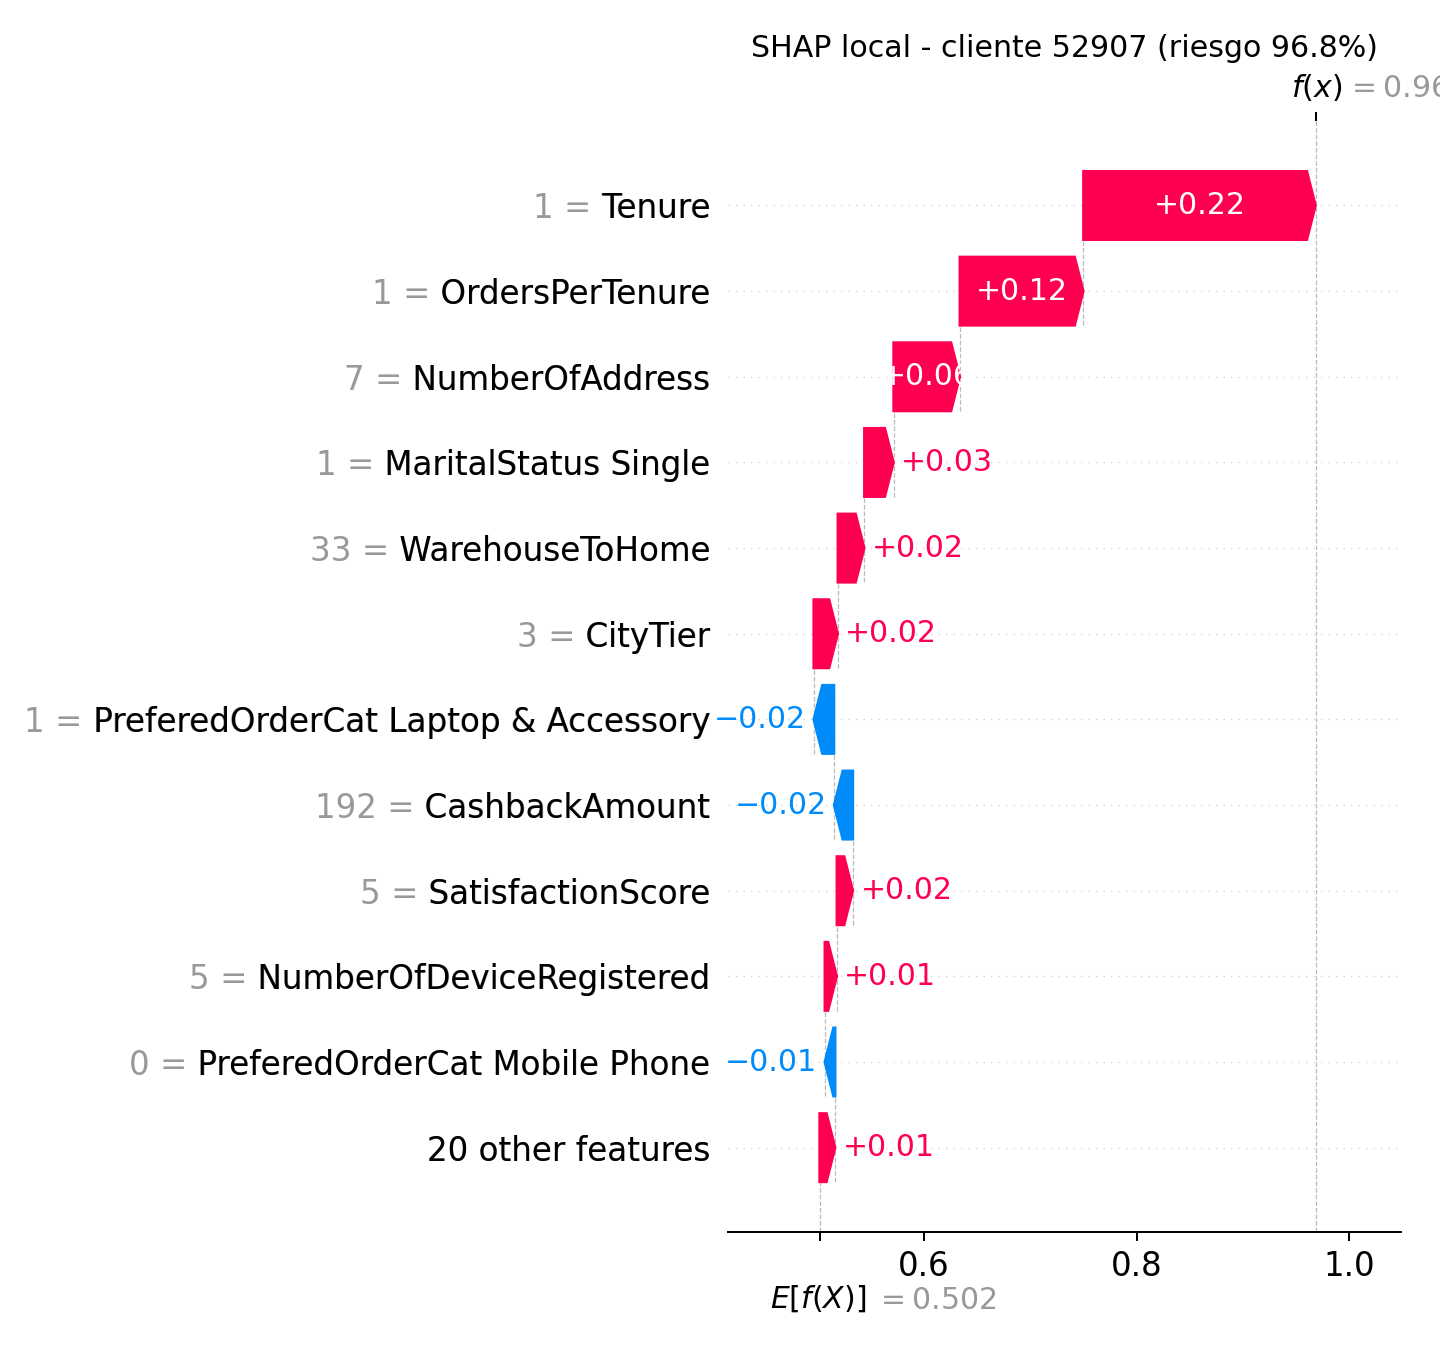

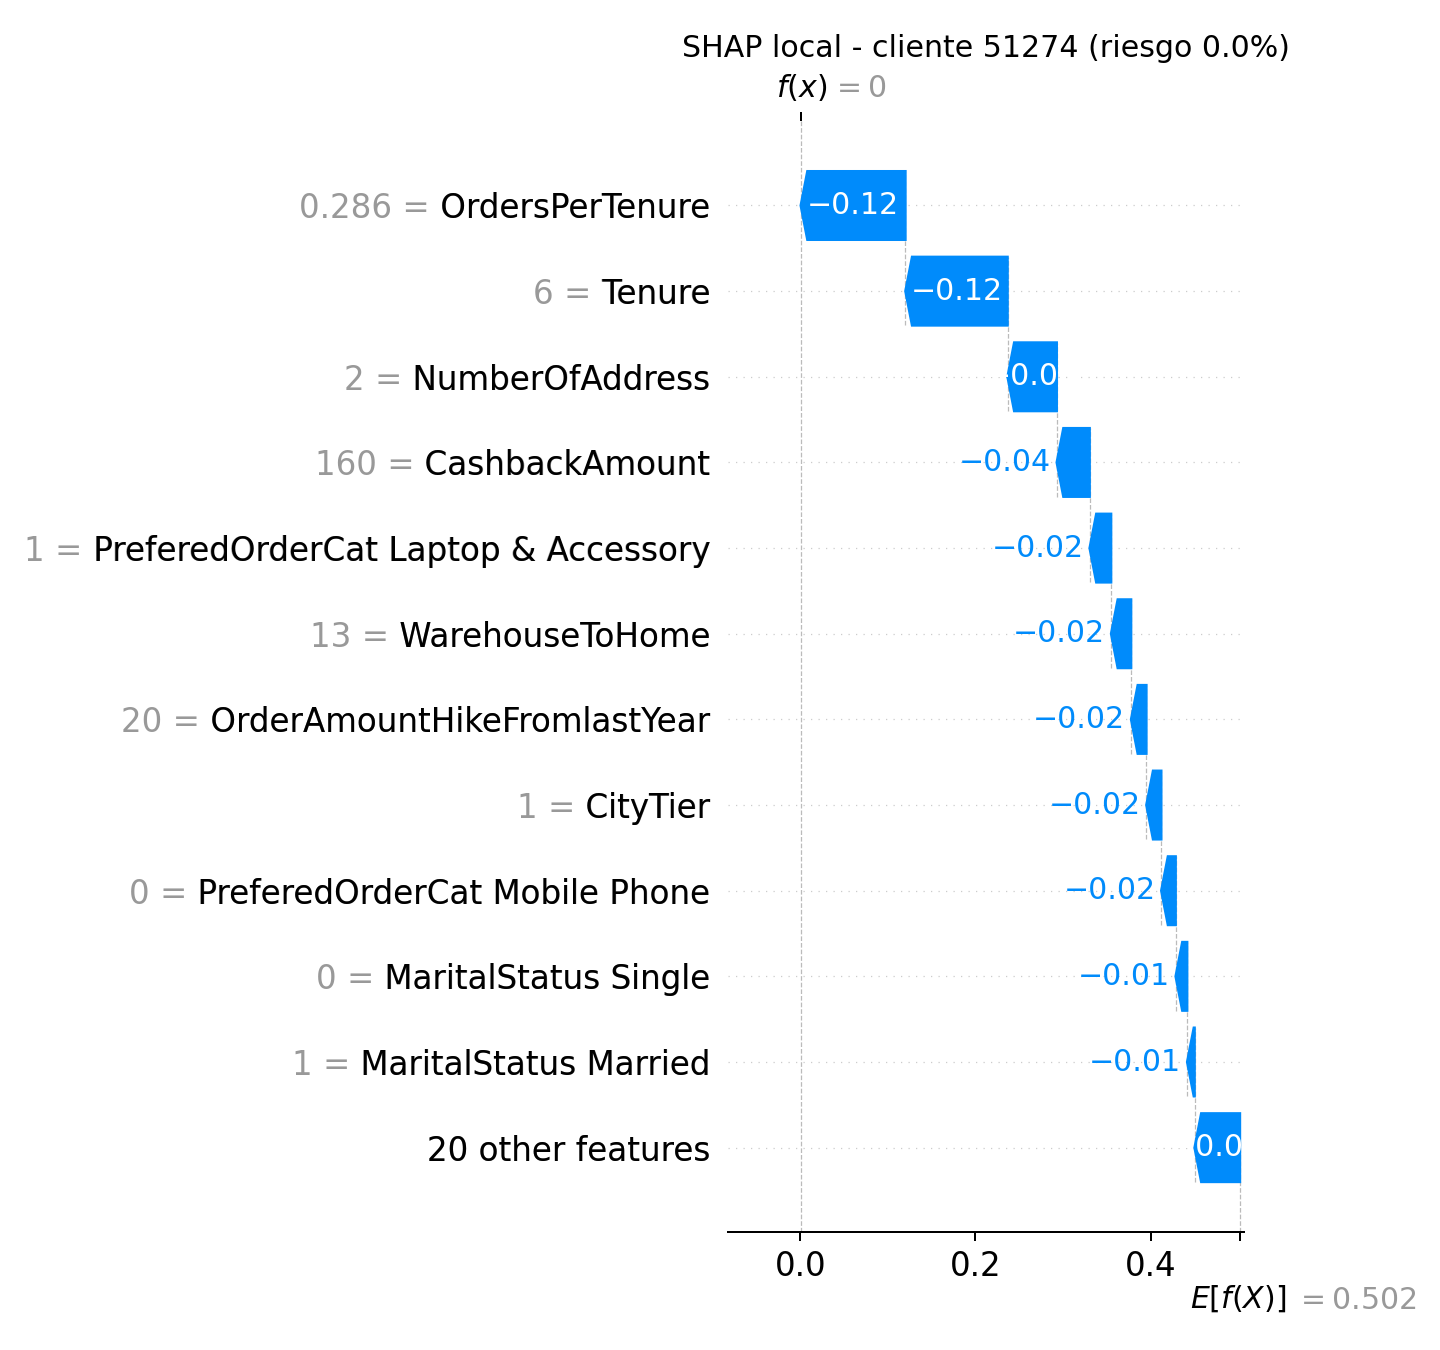

In [26]:
from pathlib import Path

from IPython.display import Image, display

# Se muestran solo las figuras que existen para el modelo final vigente.
candidate_figures = [
    "reports/figures/final_feature_importance.png",
    "reports/figures/final_shap_global.png",
    "reports/figures/final_shap_local_high_risk.png",
    "reports/figures/final_shap_local_low_risk.png",
]
shown = [fig for fig in candidate_figures if Path(fig).exists()]
for fig in shown:
    display(Image(filename=fig))
if not any("shap" in fig for fig in shown):
    print("SHAP no disponible (libreria no instalada): se muestra importancia por permutacion.")

## 17. Modelos adicionales: ExtraTrees, AdaBoost, XGBoost y LightGBM

Se entrenan cuatro modelos de ensamble adicionales para comparar contra los anteriores (Dummy, Logistic, Decision Tree, Random Forest). Se usa la misma validacion cruzada agrupada de 5 folds, las mismas features con engineering, y la misma metrica principal F2.

- **ExtraTrees:** similar a Random Forest pero con cortes aleatorios en lugar de buscar el mejor, lo que puede reducir varianza.
- **AdaBoost:** boosting secuencial que pondera mas los errores previos.
- **XGBoost:** gradient boosting optimizado con regularizacion.
- **LightGBM:** gradient boosting con particion por histograma, eficiente en datasets medianos/grandes.

In [ ]:
from sklearn.ensemble import ExtraTreesClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

churn_ratio = (y_train == 0).sum() / (y_train == 1).sum()

categorical = X_train_model.select_dtypes(include=["object", "string"]).columns.tolist()
numeric = [col for col in X_train_model.columns if col not in categorical]
median_features = ["WarehouseToHome", "CouponUsed"]
knn_numeric_features = [col for col in numeric if col not in median_features]

numeric_knn_plain = Pipeline([
    ("imputer", KNNImputer(n_neighbors=5, weights="distance")),
])
numeric_median_plain = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor_ensemble = ColumnTransformer([
    ("numeric_knn", numeric_knn_plain, knn_numeric_features),
    ("numeric_median", numeric_median_plain, median_features),
    ("categorical", categorical_pipeline, categorical),
])

new_models = {
    "ExtraTrees": Pipeline([
        ("preprocessor", preprocessor_ensemble),
        ("model", ExtraTreesClassifier(
            n_estimators=300,
            max_depth=12,
            max_features=0.5,
            min_samples_leaf=4,
            class_weight={0: 1, 1: 5},
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ]),
    "AdaBoost": Pipeline([
        ("preprocessor", preprocessor_ensemble),
        ("model", AdaBoostClassifier(
            n_estimators=200,
            learning_rate=0.1,
            random_state=RANDOM_STATE,
        )),
    ]),
    "XGBoost": Pipeline([
        ("preprocessor", preprocessor_ensemble),
        ("model", XGBClassifier(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.1,
            scale_pos_weight=churn_ratio,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=RANDOM_STATE,
            eval_metric="logloss",
            n_jobs=-1,
        )),
    ]),
    "LightGBM": Pipeline([
        ("preprocessor", preprocessor_ensemble),
        ("model", LGBMClassifier(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.1,
            scale_pos_weight=churn_ratio,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=RANDOM_STATE,
            verbose=-1,
            n_jobs=-1,
        )),
    ]),
}

print(f"Ratio desbalance (scale_pos_weight): {churn_ratio:.2f}")
print(f"Modelos nuevos definidos: {list(new_models.keys())}")

### 17.1. Validacion cruzada de los nuevos modelos

In [ ]:
new_cv_results, new_cv_raw = evaluate_model_set(new_models, X_train_model)

new_cv_results = new_cv_results.sort_values(
    ["f2_cv", "pr_auc_cv"],
    ascending=False,
).reset_index(drop=True)

display(
    new_cv_results.round({
        "recall_cv": 3, "recall_std": 3,
        "precision_cv": 3, "precision_std": 3,
        "f1_cv": 3, "f1_std": 3,
        "f2_cv": 3, "f2_std": 3,
        "pr_auc_cv": 3, "pr_auc_std": 3,
        "accuracy_cv": 3,
        "recall_train": 3, "f2_train": 3,
        "fit_time_s": 3,
    })
)

### 17.2. Matrices de confusion fuera de fold (nuevos modelos)

In [ ]:
new_oof_predictions = {}
new_oof_rows = []

fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))

for ax, (model_name, pipeline) in zip(axes, new_models.items()):
    predictions = cross_val_predict(
        pipeline, X_train_model, y_train,
        groups=train_groups, cv=cv, method="predict", n_jobs=1,
    )
    probabilities = cross_val_predict(
        pipeline, X_train_model, y_train,
        groups=train_groups, cv=cv, method="predict_proba", n_jobs=1,
    )[:, 1]

    new_oof_predictions[model_name] = {
        "predictions": predictions,
        "probabilities": probabilities,
    }

    tn, fp, fn, tp = confusion_matrix(y_train, predictions).ravel()
    new_oof_rows.append({
        "modelo": model_name,
        "verdaderos_negativos": tn,
        "falsos_positivos": fp,
        "falsos_negativos": fn,
        "verdaderos_positivos": tp,
        "clientes_contactados": int(fp + tp),
        "churn_detectado": int(tp),
        "churn_no_detectado": int(fn),
        "recall_oof": recall_score(y_train, predictions, zero_division=0),
        "precision_oof": precision_score(y_train, predictions, zero_division=0),
        "f2_oof": fbeta_score(y_train, predictions, beta=2, zero_division=0),
        "pr_auc_oof": average_precision_score(y_train, probabilities),
    })

    ConfusionMatrixDisplay.from_predictions(
        y_train, predictions,
        display_labels=["Sigue activo", "Churn"],
        cmap="Blues", colorbar=False, ax=ax,
    )
    ax.set_title(model_name)

plt.tight_layout()
new_oof_summary = pd.DataFrame(new_oof_rows)
display(new_oof_summary)

### 17.3. Comparacion global: todos los modelos

Se consolidan los resultados de validacion cruzada de los 7 modelos (3 originales + 4 nuevos) en una unica tabla y grafico para facilitar la comparacion.

In [ ]:
all_cv_results = pd.concat(
    [cv_results, new_cv_results],
    ignore_index=True,
).sort_values(["f2_cv", "pr_auc_cv"], ascending=False).reset_index(drop=True)

display(
    all_cv_results[[
        "modelo", "f2_cv", "f2_std", "recall_cv", "recall_std",
        "precision_cv", "precision_std", "pr_auc_cv", "pr_auc_std",
        "accuracy_cv", "recall_train", "f2_train", "fit_time_s",
    ]].round({
        "f2_cv": 3, "f2_std": 3,
        "recall_cv": 3, "recall_std": 3,
        "precision_cv": 3, "precision_std": 3,
        "pr_auc_cv": 3, "pr_auc_std": 3,
        "accuracy_cv": 3,
        "recall_train": 3, "f2_train": 3,
        "fit_time_s": 3,
    })
)

In [ ]:
all_plot = all_cv_results[all_cv_results["modelo"] != "Dummy - clase mayoritaria"]

metric_plot_all = all_plot.melt(
    id_vars="modelo",
    value_vars=["f2_cv", "recall_cv", "precision_cv", "f1_cv", "pr_auc_cv"],
    var_name="metrica",
    value_name="valor",
)

fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(
    data=metric_plot_all,
    x="metrica",
    y="valor",
    hue="modelo",
    ax=ax,
)
ax.set_title("Comparacion de todos los modelos en validacion cruzada (train)")
ax.set_xlabel("")
ax.set_ylabel("Media en 5 folds")
ax.set_ylim(0, 1)
ax.legend(title="Modelo", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

In [ ]:
all_oof = pd.concat(
    [oof_summary, new_oof_summary],
    ignore_index=True,
).sort_values("f2_oof", ascending=False).reset_index(drop=True)

display(
    all_oof[[
        "modelo", "f2_oof", "recall_oof", "precision_oof", "pr_auc_oof",
        "clientes_contactados", "churn_detectado", "churn_no_detectado", "falsos_positivos",
    ]].round(3)
)

best = all_oof.iloc[0]
print(
    f"\nMejor modelo por F2 fuera de fold: {best['modelo']} "
    f"(F2={best['f2_oof']:.3f}, recall={best['recall_oof']:.3f}, "
    f"precision={best['precision_oof']:.3f}, PR-AUC={best['pr_auc_oof']:.3f})"
)

### 17.4. Lectura de la comparacion

La tabla anterior ordena los 7 modelos por F2 en validacion cruzada. Puntos a observar:

- **F2 y recall:** los modelos de boosting (XGBoost, LightGBM) y los basados en bagging (ExtraTrees, Random Forest) suelen superar a la logistica y al arbol simple en la capacidad de ordenar riesgo.
- **Precision vs recall:** los modelos de ensamble tienden a mejorar precision sin resignar tanto recall, porque ordenan mejor las probabilidades.
- **PR-AUC:** resume la calidad del ranking de riesgo independientemente del umbral. Un PR-AUC mas alto significa mas margen para ajustar el umbral segun la capacidad de contacto del negocio.
- **Sobreajuste:** comparar recall y F2 en train vs CV. Un gap grande indica que el modelo memoriza patrones de train.
- **Tiempo de ajuste:** AdaBoost suele ser mas lento que LightGBM por su naturaleza secuencial.

Esta comparacion usa las mismas features (con engineering) y la misma CV agrupada. No se toco test. Si alguno de estos modelos supera al Random Forest tuneado de la seccion 12 bis, seria candidato a una busqueda de hiperparametros dedicada antes de evaluar en test.

### 17.5. Importancia por permutacion (los 4 modelos nuevos)

Se entrena cada modelo con todo train y se mide cuanto cae F2 al permutar cada variable en train (out-of-bag no aplica a todos, asi que se usa train completo como referencia relativa). Esto permite comparar que variables pesa cada modelo.

In [ ]:
from sklearn.inspection import permutation_importance

fitted_new_models = {}
for name, pipeline in new_models.items():
    fitted_new_models[name] = pipeline.fit(X_train_model, y_train)

feature_names_new = fitted_new_models[list(new_models.keys())[0]]["preprocessor"].get_feature_names_out()

f2_scorer_perm = make_scorer(fbeta_score, beta=2, zero_division=0)

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

perm_results = {}
for ax, (name, pipeline) in zip(axes.flat, fitted_new_models.items()):
    result = permutation_importance(
        pipeline, X_train_model, y_train,
        scoring=f2_scorer_perm,
        n_repeats=10,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    importance = pd.DataFrame({
        "variable": feature_names_new,
        "importancia_media": result.importances_mean,
        "importancia_std": result.importances_std,
    }).sort_values("importancia_media", ascending=False).reset_index(drop=True)

    perm_results[name] = importance

    top = importance.head(12).sort_values("importancia_media")
    ax.barh(top["variable"], top["importancia_media"], xerr=top["importancia_std"], color="#4C78A8")
    ax.set_xlabel("Caida media de F2 al permutar")
    ax.set_title(f"{name}")
    ax.grid(axis="x", alpha=0.25)

plt.suptitle("Importancia por permutacion - Top 12 variables por modelo", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
top_n = 10
perm_comparison = pd.DataFrame()
for name, imp in perm_results.items():
    top = imp.head(top_n).copy()
    top["modelo"] = name
    perm_comparison = pd.concat([perm_comparison, top], ignore_index=True)

fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(
    data=perm_comparison,
    x="importancia_media",
    y="variable",
    hue="modelo",
    ax=ax,
)
ax.set_xlabel("Caida media de F2 al permutar")
ax.set_ylabel("")
ax.set_title("Top 10 variables por permutacion - Comparacion entre modelos")
ax.legend(title="Modelo", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

### 17.6. SHAP del mejor modelo nuevo

Se aplica SHAP TreeExplainer al modelo con mayor F2 en CV entre los 4 nuevos. Se muestran:

- **SHAP global:** que variables contribuyen mas a las predicciones en promedio.
- **SHAP beeswarm:** como se distribuyen las contribuciones por variable y valor.
- **SHAP local:** explicacion de un caso de alto riesgo y uno de bajo riesgo.

In [ ]:
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    shap = None
    SHAP_AVAILABLE = False

best_new_model_name = new_cv_results.iloc[0]["modelo"]
best_new_pipeline = fitted_new_models[best_new_model_name]

print(f"Mejor modelo nuevo por F2 CV: {best_new_model_name}")
print(f"SHAP disponible: {SHAP_AVAILABLE}")

if not SHAP_AVAILABLE:
    print("Instalar shap con: pip install shap")

In [ ]:
if SHAP_AVAILABLE:
    preprocessor = best_new_pipeline["preprocessor"]
    model_step = best_new_pipeline["model"]

    X_transformed = preprocessor.transform(X_train_model)
    if hasattr(X_transformed, "toarray"):
        X_transformed = X_transformed.toarray()

    sample_size = min(500, X_transformed.shape[0])
    sample_idx = np.linspace(0, X_transformed.shape[0] - 1, sample_size, dtype=int)
    X_sample = X_transformed[sample_idx]

    explainer = shap.TreeExplainer(model_step)
    shap_values_raw = explainer.shap_values(X_sample)

    if isinstance(shap_values_raw, list):
        shap_values_pos = np.asarray(shap_values_raw[1])
    elif np.asarray(shap_values_raw).ndim == 3:
        shap_values_pos = np.asarray(shap_values_raw)[:, :, 1]
    else:
        shap_values_pos = np.asarray(shap_values_raw)

    transformed_feature_names = preprocessor.get_feature_names_out()

    # SHAP global bar
    shap_global = pd.DataFrame({
        "variable": transformed_feature_names,
        "mean_abs_shap": np.abs(shap_values_pos).mean(axis=0),
    }).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

    top_shap = shap_global.head(15).sort_values("mean_abs_shap")
    fig, ax = plt.subplots(figsize=(10, 7))
    ax.barh(top_shap["variable"], top_shap["mean_abs_shap"], color="#70AD47")
    ax.set_xlabel("Impacto SHAP medio absoluto")
    ax.set_title(f"SHAP global - {best_new_model_name}")
    ax.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    plt.show()

    display(shap_global.head(15))
else:
    print("SHAP no disponible. Se muestra solo importancia por permutacion.")

In [ ]:
if SHAP_AVAILABLE:
    # Beeswarm plot
    explanation = shap.Explanation(
        values=shap_values_pos,
        base_values=np.full(shap_values_pos.shape[0], explainer.expected_value if np.isscalar(explainer.expected_value) else explainer.expected_value[1]),
        data=X_sample,
        feature_names=list(transformed_feature_names),
    )
    fig, ax = plt.subplots(figsize=(10, 8))
    shap.plots.beeswarm(explanation, max_display=15, show=False)
    plt.title(f"SHAP beeswarm - {best_new_model_name}")
    plt.tight_layout()
    plt.show()

In [ ]:
if SHAP_AVAILABLE:
    # SHAP local: caso de alto riesgo y bajo riesgo
    probabilities_train = best_new_pipeline.predict_proba(X_train_model)[:, 1]
    high_risk_idx = int(np.argmax(probabilities_train))
    low_risk_idx = int(np.argmin(probabilities_train))

    expected_val = explainer.expected_value if np.isscalar(explainer.expected_value) else explainer.expected_value[1]

    for label, idx in [("Alto riesgo", high_risk_idx), ("Bajo riesgo", low_risk_idx)]:
        row_transformed = preprocessor.transform(X_train_model.iloc[[idx]])
        if hasattr(row_transformed, "toarray"):
            row_transformed = row_transformed.toarray()

        row_shap = explainer.shap_values(row_transformed)
        if isinstance(row_shap, list):
            row_shap_pos = np.asarray(row_shap[1])[0]
        elif np.asarray(row_shap).ndim == 3:
            row_shap_pos = np.asarray(row_shap)[0, :, 1]
        else:
            row_shap_pos = np.asarray(row_shap)[0]

        row_explanation = shap.Explanation(
            values=row_shap_pos,
            base_values=expected_val,
            data=np.asarray(row_transformed)[0],
            feature_names=list(transformed_feature_names),
        )
        print(f"\n{label} (prob={probabilities_train[idx]:.3f}):")
        fig, ax = plt.subplots(figsize=(12, 4))
        shap.plots.waterfall(row_explanation, max_display=12, show=False)
        plt.title(f"SHAP local - {label} - {best_new_model_name}")
        plt.tight_layout()
        plt.show()